<br><br>
<span style="font-family: Courier New; font-size: 20px; font-weight: bold;">  
SC1015 Final Mini-Project // Formula 1
</span>
<br><br>

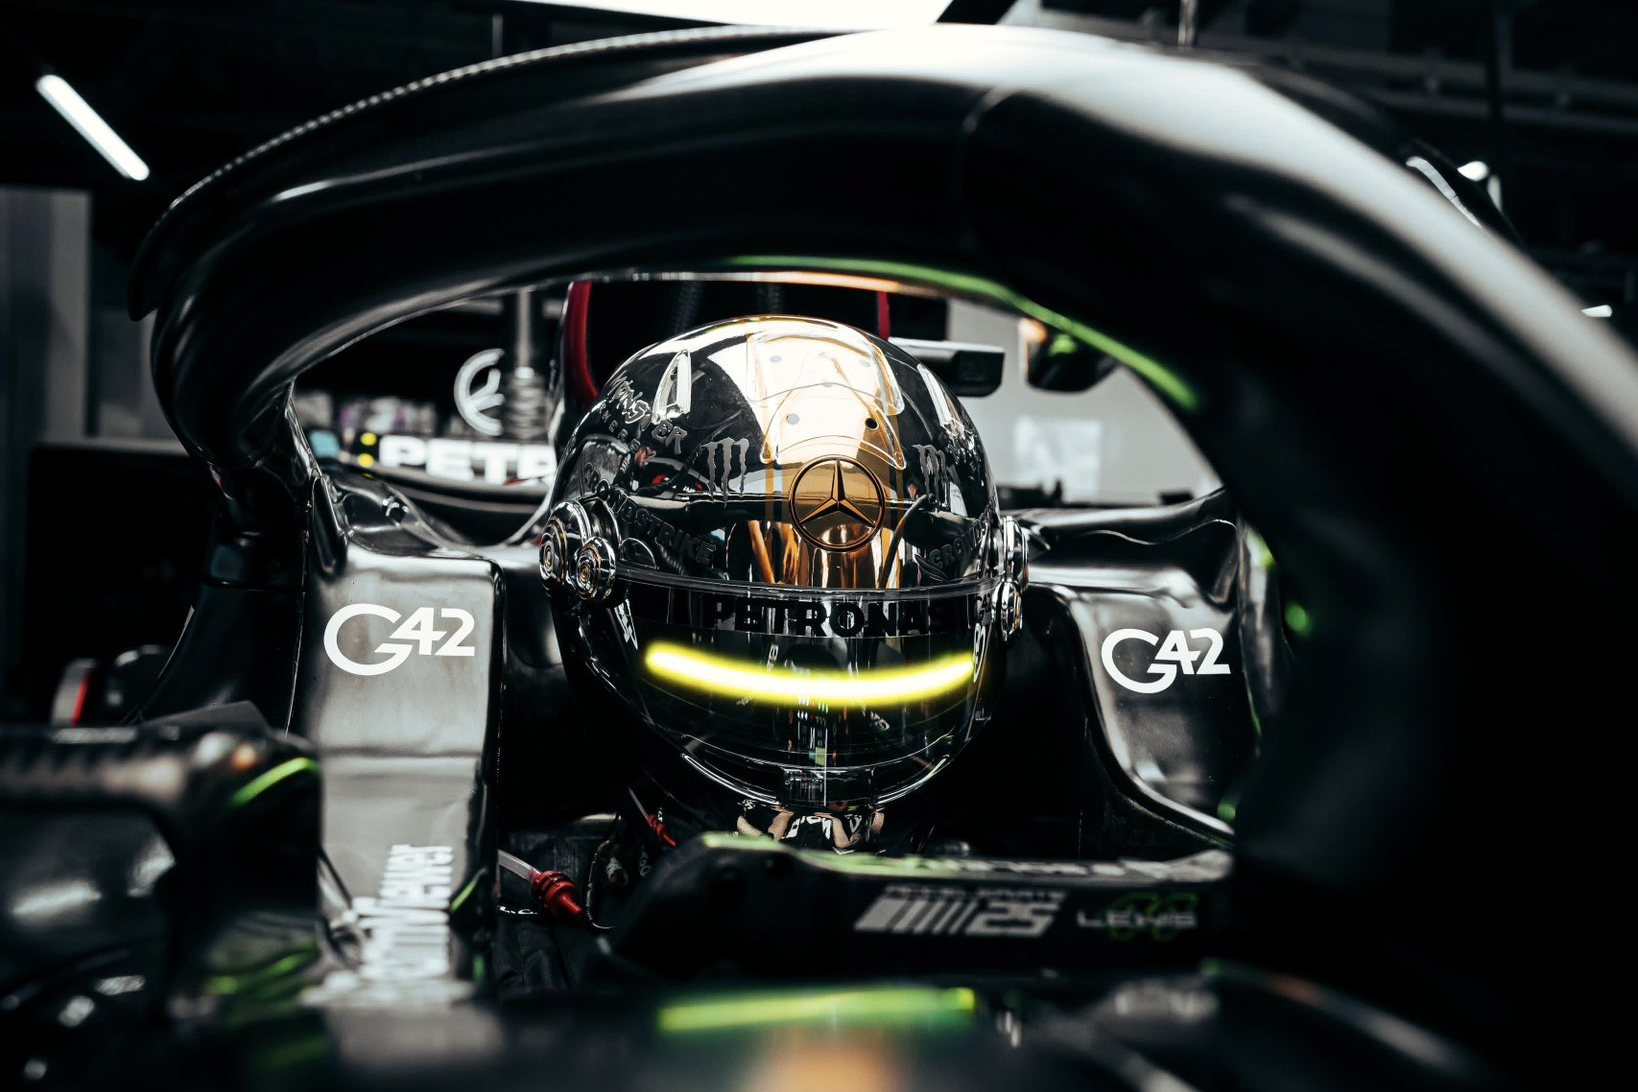

In [105]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import requests
import re
import datetime
import seaborn as sb
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', 1000)

In [2]:
drivers = pd.read_csv('/Users/adisontan/Downloads/driversgit.csv')
laptimes = pd.read_csv('/Users/adisontan/Downloads/laptimesgit.csv')
qualifying = pd.read_csv('/Users/adisontan/Downloads/qualifyinggit.csv') 
races = pd.read_csv('/Users/adisontan/Downloads/racesgit.csv') 
sgppits = pd.read_csv('/Users/adisontan/Downloads/sgppitsgitfinal.csv') 
results = pd.read_csv('/Users/adisontan/Downloads/resultsgit.csv') 
weather = pd.read_csv('/Users/adisontan/Downloads/weatherdescriptiongit.csv') 

In [3]:
drivers.head(5)

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [4]:
laptimes.head(5)

,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342


In [5]:
qualifying.head(5)

,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236


In [6]:
races.head(5)

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [7]:
sgppits.head(5)

,Unnamed: 0,duration,stop,driverId,raceId
0,0,44.170,1,817,2011
1,1,29.549,1,3,2011
2,2,30.621,1,4,2011
3,3,29.610,1,30,2011
4,4,35.398,1,811,2011


In [8]:
results.head(5)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


In [9]:
weather.head(5)

,Unnamed: 0,year,name,race_id,weather_description,is_it_wet
0,0,1950,French Grand Prix,838,Hot and sunny,Not Wet
1,1,1950,Belgian Grand Prix,837,"Warm, dry and sunny",Not Wet
2,2,1950,British Grand Prix,833,"Sunny, mild, dry.",Not Wet
3,3,1950,Indianapolis 500,835,Rainy,Wet
4,4,1950,Monaco Grand Prix,834,No weather description,Not Wet


<br><br>
<span style="font-family: Courier New; font-size: 30px; font-weight: bold;">  
INITIAL DATA INSIGHTS
</span>
<br><br><br>

## Extracting Singapore Grand Prix Data from .csv files following our problem statement

In [10]:
# matches the driver codes to the driverId

driversdf = drivers[['code', 'driverId']]
driversdf = driversdf.dropna()
driversdf.head()

# extract Singapore Grand Prix raceId and year

sgpraces = races.loc[races['circuitId'] == 15, ['raceId']] #14 is 2009, #32 is 2008, #351 is 2010, #854 is 2011, #873 is 2012, #893 is 2013, #913 is 2014, #939 is 2015, #962 is 2016, #982 is 2017, #1003 is 2018, #1024 is 2019, #1091 is 2022
sgpIds = []
sgpIds.extend(sgpraces.raceId) # compile all singapore raceIds into a list
sgplaptimes = laptimes.loc[laptimes['raceId'].isin(sgpIds)] # laptimes for all drivers for all sgp GPs

# extract Singapore Grand Prix starting grid position

sgpgriddf = qualifying.loc[qualifying['raceId'].isin(sgpIds)]
sgpgrid = sgpgriddf[['raceId', 'position', 'driverId']]
sgpgrid.rename(columns={'position': 'grid'}, inplace=True)

# extract Singapore Grand Prix points and fastest lap timing

sgpresultsdf = results.loc[results['raceId'].isin(sgpIds)]
sgpresults = sgpresultsdf[['raceId', 'driverId', 'constructorId', 'points', 'fastestLapTime', 'position']]
sgpresults = sgpresults.sort_values(by='raceId')

# extract Singapore Grand Prix weather condition

sgpweatherdf = weather.loc[weather['race_id'].isin(sgpIds)]
sgpweather = sgpweatherdf[['is_it_wet', 'race_id']]
sgpweather.rename(columns={'is_it_wet': 'weather', 'race_id': 'raceId'}, inplace=True)

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_80166/2270689871.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sgpgrid.rename(columns={'position': 'grid'}, inplace=True)
/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_80166/2270689871.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sgpweather.rename(columns={'is_it_wet': 'weather', 'race_id': 'raceId'}, inplace=True)


In [11]:
print(sgplaptimes.info())
print()
print(sgplaptimes)

<class 'pandas.core.frame.DataFrame'>
Index: 14661 entries, 16314 to 532875
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   raceId        14661 non-null  int64 
 1   driverId      14661 non-null  int64 
 2   lap           14661 non-null  int64 
 3   position      14661 non-null  int64 
 4   time          14661 non-null  object
 5   milliseconds  14661 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 801.8+ KB
None

        raceId  driverId  lap  position      time  milliseconds
16314      854        20    1         1  1:56.910        116910
16315      854        20    2         1  1:55.464        115464
16316      854        20    3         1  1:54.935        114935
16317      854        20    4         1  1:54.261        114261
16318      854        20    5         1  1:53.910        113910
...        ...       ...  ...       ...       ...           ...
532871    1091       848   21        16  2:20.921 

In [12]:
print(sgppits.info())
print()
print(sgppits)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  600 non-null    int64  
 1   duration    600 non-null    float64
 2   stop        600 non-null    int64  
 3   driverId    600 non-null    int64  
 4   raceId      600 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 23.6 KB
None

     Unnamed: 0  duration  stop  driverId  raceId
0             0    44.170     1       817    2011
1             1    29.549     1         3    2011
2             2    30.621     1         4    2011
3             3    29.610     1        30    2011
4             4    35.398     1       811    2011
5             5    30.290     1        13    2011
6             6    30.142     1         1    2011
7             7    30.718     1        16    2011
8             8    30.888     1       813    2011
9             9    32.827     1        67    2011
10

In [13]:
print(sgpresults.info())
print()
print(sgpresults)

<class 'pandas.core.frame.DataFrame'>
Index: 278 entries, 7830 to 25739
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   raceId          278 non-null    int64  
 1   driverId        278 non-null    int64  
 2   constructorId   278 non-null    int64  
 3   points          278 non-null    float64
 4   fastestLapTime  278 non-null    object 
 5   position        278 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 15.2+ KB
None

       raceId  driverId  constructorId  points fastestLapTime position
7830       14        16             10     0.0       1:52.623       \N
7815       14         4              4     6.0       1:48.240        3
7816       14        20              9     5.0       1:48.398        4
7817       14        18             23     4.0       1:48.369        5
7818       14        22             23     3.0       1:48.598        6
7819       14         5              1   

<br><br>
<span style="font-family: Courier New; font-size: 30px; font-weight: bold;">  
DATA PREPARATION AND CLEANING
</span>
<br><br><br>

In [14]:
# function defintion for adding 'position' column to dataframe

def add_position(df):
    df['position'] = ""
    index2 = -1
    for i in df.iterrows():
        index1 = 0
        index2 += 1
        for j in sgpresults.iterrows():
            if(sgpresults['raceId'].values[index1] == df['raceId'].values[index2] and sgpresults['driverId'].values[index1] == df['driverId'].values[index2]):
                df.loc[index2, 'position'] = sgpresults['position'].values[index1]
                break
            else:
                index1 += 1

In [15]:
# function definition for changing driverId to driver code/name

def add_drivers(df):
    driverslist = driversdf.set_index('driverId').T.to_dict('records') 
    for i in driverslist:
        driversdict = i
    df['driverId'] = df['driverId'].map(driversdict)

In [16]:
# function defintion for changing raceId to year of race

def add_years(df):
    j = 0
    years = [2009, 2008, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2022]
    for i in sgpIds:
        updated = df['raceId'] == i
        df.loc[updated, 'raceId'] = years[j]
        j += 1

In [17]:
# change the position of the drivers to show top 5 , not top 5 and DNF

add_years(sgpresults)
sgpresults.loc[sgpresults['position'] == '\\N', 'position'] = 0 # set DNF to 0
sgpresults['position'] = sgpresults['position'].astype(str).astype(int)
for i in sgpresults['position']:
    if (i >= 1 and i <= 5): 
        sgpresults.loc[sgpresults['position'] == i, 'position'] = 1 # set drivers who finish in top 5 to 1
    elif (i <= 0):
        continue
    elif (i > 5 and i <= 22):
        sgpresults.loc[sgpresults['position'] == i, 'position'] = 0 # set drivers who finish outside of top 5 to 0

In [18]:
# calculate the average pitstop time for each driver for every edition of the Singapore Grand Prix. pitdf is the df for the average pit times for all drivers for all sgp grand prixs over the years.

sgppits = sgppits.drop(columns='Unnamed: 0') # clean sgppits data
pitcolumns = ['averagepit(s)', 'raceId', 'driverId']
driverdf = drivers.drop_duplicates(subset=['driverId'], keep='last')
pitdf = pd.DataFrame(columns=pitcolumns)
driverlist = driverdf['driverId'].tolist()
stoplist = driverdf['driverId'].tolist()
stopdict = {}
driverdict = {}
sgppits['duration'] = sgppits['duration'].astype(float)
index = 0
curraceid = 0
preraceid = sgppits['raceId'].values[0]
avetime = 0
dfindex = 0
j = 0
for j in driverlist:
    driverdict[j] = 0
    stopdict[j] = 0
for i in sgppits.iterrows():
    curraceid = sgppits['raceId'].values[index]
    if (curraceid == preraceid):
        time = sgppits['duration'].values[index]
        driverId = sgppits['driverId'].values[index]
        stopno = sgppits['stop'].values[index]
        curtime = driverdict[driverId]
        driverdict[driverId] = curtime + time
        if (stopdict[driverId] < stopno):
            stopdict[driverId] = stopno
        index += 1
        preraceid = curraceid
        continue
    else:
        for k in driverdict:
            if (driverdict[k] != 0):
                avetime = round(driverdict[k]/stopdict[k], 3)
                pitdf.loc[dfindex] = [avetime, preraceid, k]
                dfindex += 1
            else:
                continue
        for x in driverdict:
            driverdict[x] = 0
            stopdict[x] = 0
        preraceid = curraceid
pitdf['raceId'] = pitdf['raceId'].astype(int)
pitdf['driverId'] = pitdf['driverId'].astype(int)

In [19]:
# calculate the average laptime for each driver for every edition of the Singapore Grand Prix. timedf is the df for the average laptimes for all drivers for all sgp grand prixs over the years.

timesum = 0
index = 0
newindex = 0
dfindex = 0
columns = ['averagelaptime', 'averagelaptime(ms)', 'raceId', 'driverId']
timedf = pd.DataFrame(columns=columns)
prename =  sgplaptimes['driverId'].values[index]
raceyear =  sgplaptimes['raceId'].values[index]
for i in sgplaptimes.iterrows():
    name = sgplaptimes['driverId'].values[index]
    if (name != prename):
        average = timesum//lapnum
        sec = average // 1000
        mins = sec // 60
        rem_sec = sec % 60
        m_sec = (average - (mins*60*1000) - (rem_sec*1000))*1000
        format_time = datetime.time(0, mins, rem_sec, m_sec)
        time = '{:02d}:{:02d}.{:03d}'.format(format_time.minute, format_time.second, format_time.microsecond // 1000)
        timedf.loc[dfindex] = [time, average, raceyear, prename]
        dfindex += 1
        timesum = 0
    prename =  sgplaptimes['driverId'].values[index]
    time = sgplaptimes['milliseconds'].values[index]
    timesum = timesum + time
    lapnum = sgplaptimes['lap'].values[index]
    raceyear =  sgplaptimes['raceId'].values[index]
    index += 1   
timedf = timedf.sort_values(by='raceId')

In [20]:
# extract fastestlaptime and convert to ms for eda

timesum = 0
index = 0
newindex = 0
dfindex = 0
columns = ['fastestlaptime', 'fastestlaptime(ms)', 'raceId', 'driverId']
sgpresults.loc[sgpresults['fastestLapTime'] == '\\N', 'fastestLapTime'] = 0
fastestdf = pd.DataFrame(columns=columns)
raceyear =  sgpresults['raceId'].values[index]
for i in sgpresults.iterrows():
    name = sgpresults['driverId'].values[index]
    time = sgpresults['fastestLapTime'].values[index]
    raceyear =  sgpresults['raceId'].values[index]
    if time != 0:
        time_str = str(time)
        mins, seconds = map(float, time_str.split(':'))
        secs, milliseconds = divmod(seconds, 1)
        ms = milliseconds * 1000
        timems = int((mins * 60 * 1000) + (secs * 1000) + ms)
    else:
        index += 1
        continue
    fastestdf.loc[dfindex] = [time, timems, raceyear, name]
    index += 1
    dfindex += 1

In [21]:
# create weatherdf by merging weather condition with raceId and how it affects their position

index2 = -1
weatherdf = pd.DataFrame(timedf[["raceId", "driverId", "averagelaptime(ms)"]])
weatherdf['weather'] = ""
for i in weatherdf.iterrows():
    index1 = 0
    index2 += 1
    for j in sgpweather.iterrows():
        if(sgpweather['raceId'].values[index1] == weatherdf['raceId'].values[index2]):
            weatherdf['weather'].values[index2] = sgpweather['weather'].values[index1]
            break
        else:
            index1 += 1

In [22]:
# change raceId into the year of the race

add_years(timedf)
add_years(sgpgrid)
add_years(sgpweather)
add_years(fastestdf)
add_years(weatherdf)

# arrange the data by ascending order 

pitdf = pitdf.sort_values(by=['raceId'], ascending=True)
sgpresults = sgpresults.sort_values(by=['raceId'], ascending=True)
timedf = timedf.sort_values(by=['raceId'], ascending=True)
fastestdf = fastestdf.sort_values(by=['raceId'], ascending=True)
griddf = sgpgrid.sort_values(by=['raceId'], ascending=True)
sgpresults = sgpresults.sort_values(by=["raceId","position"])

# reset index of the data

timedf = timedf.reset_index(drop=True)
pitdf = pitdf.reset_index(drop=True)
griddf = griddf.reset_index(drop=True)
fastestdf = fastestdf.reset_index(drop=True)

# add position of drivers to dataframe for EDA

add_position(timedf)
add_position(pitdf)
add_position(griddf)
add_position(fastestdf)
       
# change driverId into name for all dfs

add_drivers(timedf)
add_drivers(pitdf)
add_drivers(griddf)
add_drivers(sgpresults)
add_drivers(fastestdf)
add_drivers(weatherdf)

# arrange the data by ascending order based off their position

pitdf.sort_values(['raceId', 'position'], ascending=[True, True])
sgpresults = sgpresults.sort_values(by=['raceId'], ascending=True)
timedf = timedf.sort_values(['raceId', 'position'], ascending=[True, True])
griddf.sort_values(['raceId', 'position'], ascending=[True, True])
fastestdf = fastestdf.sort_values(['raceId', 'position'], ascending=[True, True])
sgpresults = sgpresults.sort_values(by=["raceId", 'position'])
weatherdf = weatherdf.sort_values(by=["raceId"], ascending=[True])

# reset index of the data

timedf = timedf.reset_index(drop=True)
pitdf = pitdf.reset_index(drop=True)
griddf = griddf.reset_index(drop=True)
fastestdf = fastestdf.reset_index(drop=True)
weatherdf = weatherdf.reset_index(drop=True)

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_80166/4125253322.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[updated, 'raceId'] = years[j]


In [23]:
timedf.head(5)

,averagelaptime,averagelaptime(ms),raceId,driverId,position
0,01:56.063,116063,2008,FIS,0
1,01:56.013,116013,2008,SUT,0
2,01:52.792,112792,2008,BAR,0
3,01:55.675,115675,2008,BUT,0
4,01:55.831,115831,2008,BOU,0


In [24]:
pitdf.head(5)

,averagepit(s),raceId,driverId,position
0,31.375,2008,FIS,0
1,28.133,2008,VET,1
2,26.919,2008,BUT,0
3,31.518,2008,WEB,0
4,29.138,2008,SUT,0


In [25]:
griddf.head(5)

,raceId,grid,driverId,position
0,2008,1,MAS,0
1,2008,20,FIS,0
2,2008,19,SUT,0
3,2008,18,BAR,0
4,2008,17,BOU,0


In [26]:
fastestdf.head(5)

,fastestlaptime,fastestlaptime(ms),raceId,driverId,position
0,1:46.972,106972,2008,TRU,0
1,1:50.449,110449,2008,PIQ,0
2,1:47.306,107306,2008,HEI,0
3,1:47.562,107562,2008,COU,0
4,1:47.287,107287,2008,NAK,0


In [27]:
weatherdf.head(5)

,raceId,driverId,averagelaptime(ms),weather
0,2008,ALO,115349,Not Wet
1,2008,HAM,115446,Not Wet
2,2008,FIS,116063,Not Wet
3,2008,SUT,116013,Not Wet
4,2008,BAR,112792,Not Wet


In [28]:
# merge the variables from different dataframes into one dataframe merge_df3

merge_df1 = pd.merge(pitdf, timedf, on=['driverId', 'raceId'], how='outer')
merge_df2 = pd.merge(merge_df1, fastestdf, on=['driverId', 'raceId'], how='outer')
merge_df2 = pd.DataFrame(merge_df2[['driverId', 'raceId', 'averagepit(s)', 'averagelaptime(ms)', 'fastestlaptime(ms)']])
merge_df3 = pd.merge(merge_df2, griddf, on=['driverId', 'raceId'], how='outer')

In [29]:
# Merged Data Frame with all the values
merge_df3.head(5)

,driverId,raceId,averagepit(s),averagelaptime(ms),fastestlaptime(ms),grid,position
0,FIS,2008,31.375,116063.0,109101.0,20,0
1,VET,2008,28.133,115517.0,107271.0,7,1
2,BUT,2008,26.919,115675.0,108128.0,12,0
3,WEB,2008,31.518,120278.0,109183.0,13,0
4,SUT,2008,29.138,116013.0,109270.0,19,0


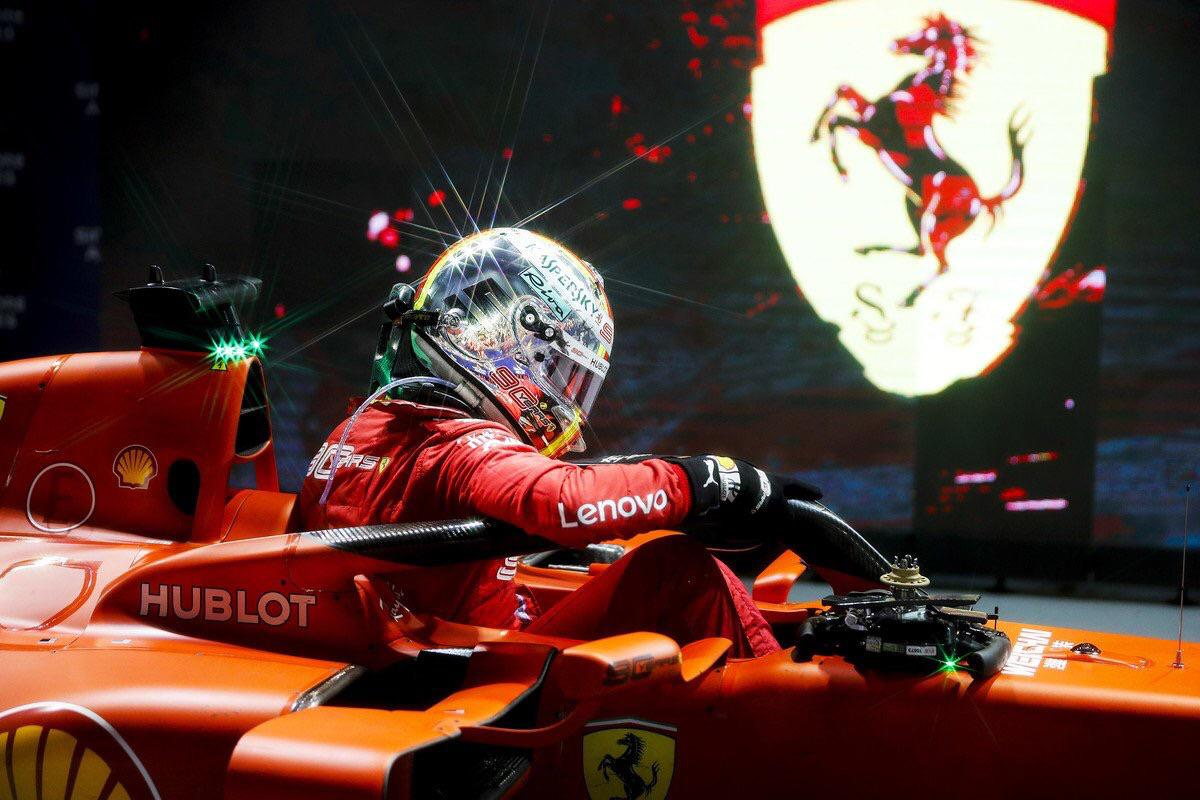

<br><br>
<span style="font-family: Courier New; font-size: 30px; font-weight: bold;">  
EXPLORATORY DATA ANALYSIS
</span>
<br><br><br>

<span style="font-family: Courier New; font-size: 20px; font-weight: bold;">  
UNI-VARIATE STATISTICS // EXPLORATORY DATA ANALYSIS
</span>
<br><br><br>

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_80166/1565427905.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(timedf_eda_uni, kde = True, color = "b", ax = axes[0, 1]) # distplot for averagelaptime
/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_80166/1565427905.py:16: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/d

<Axes: >

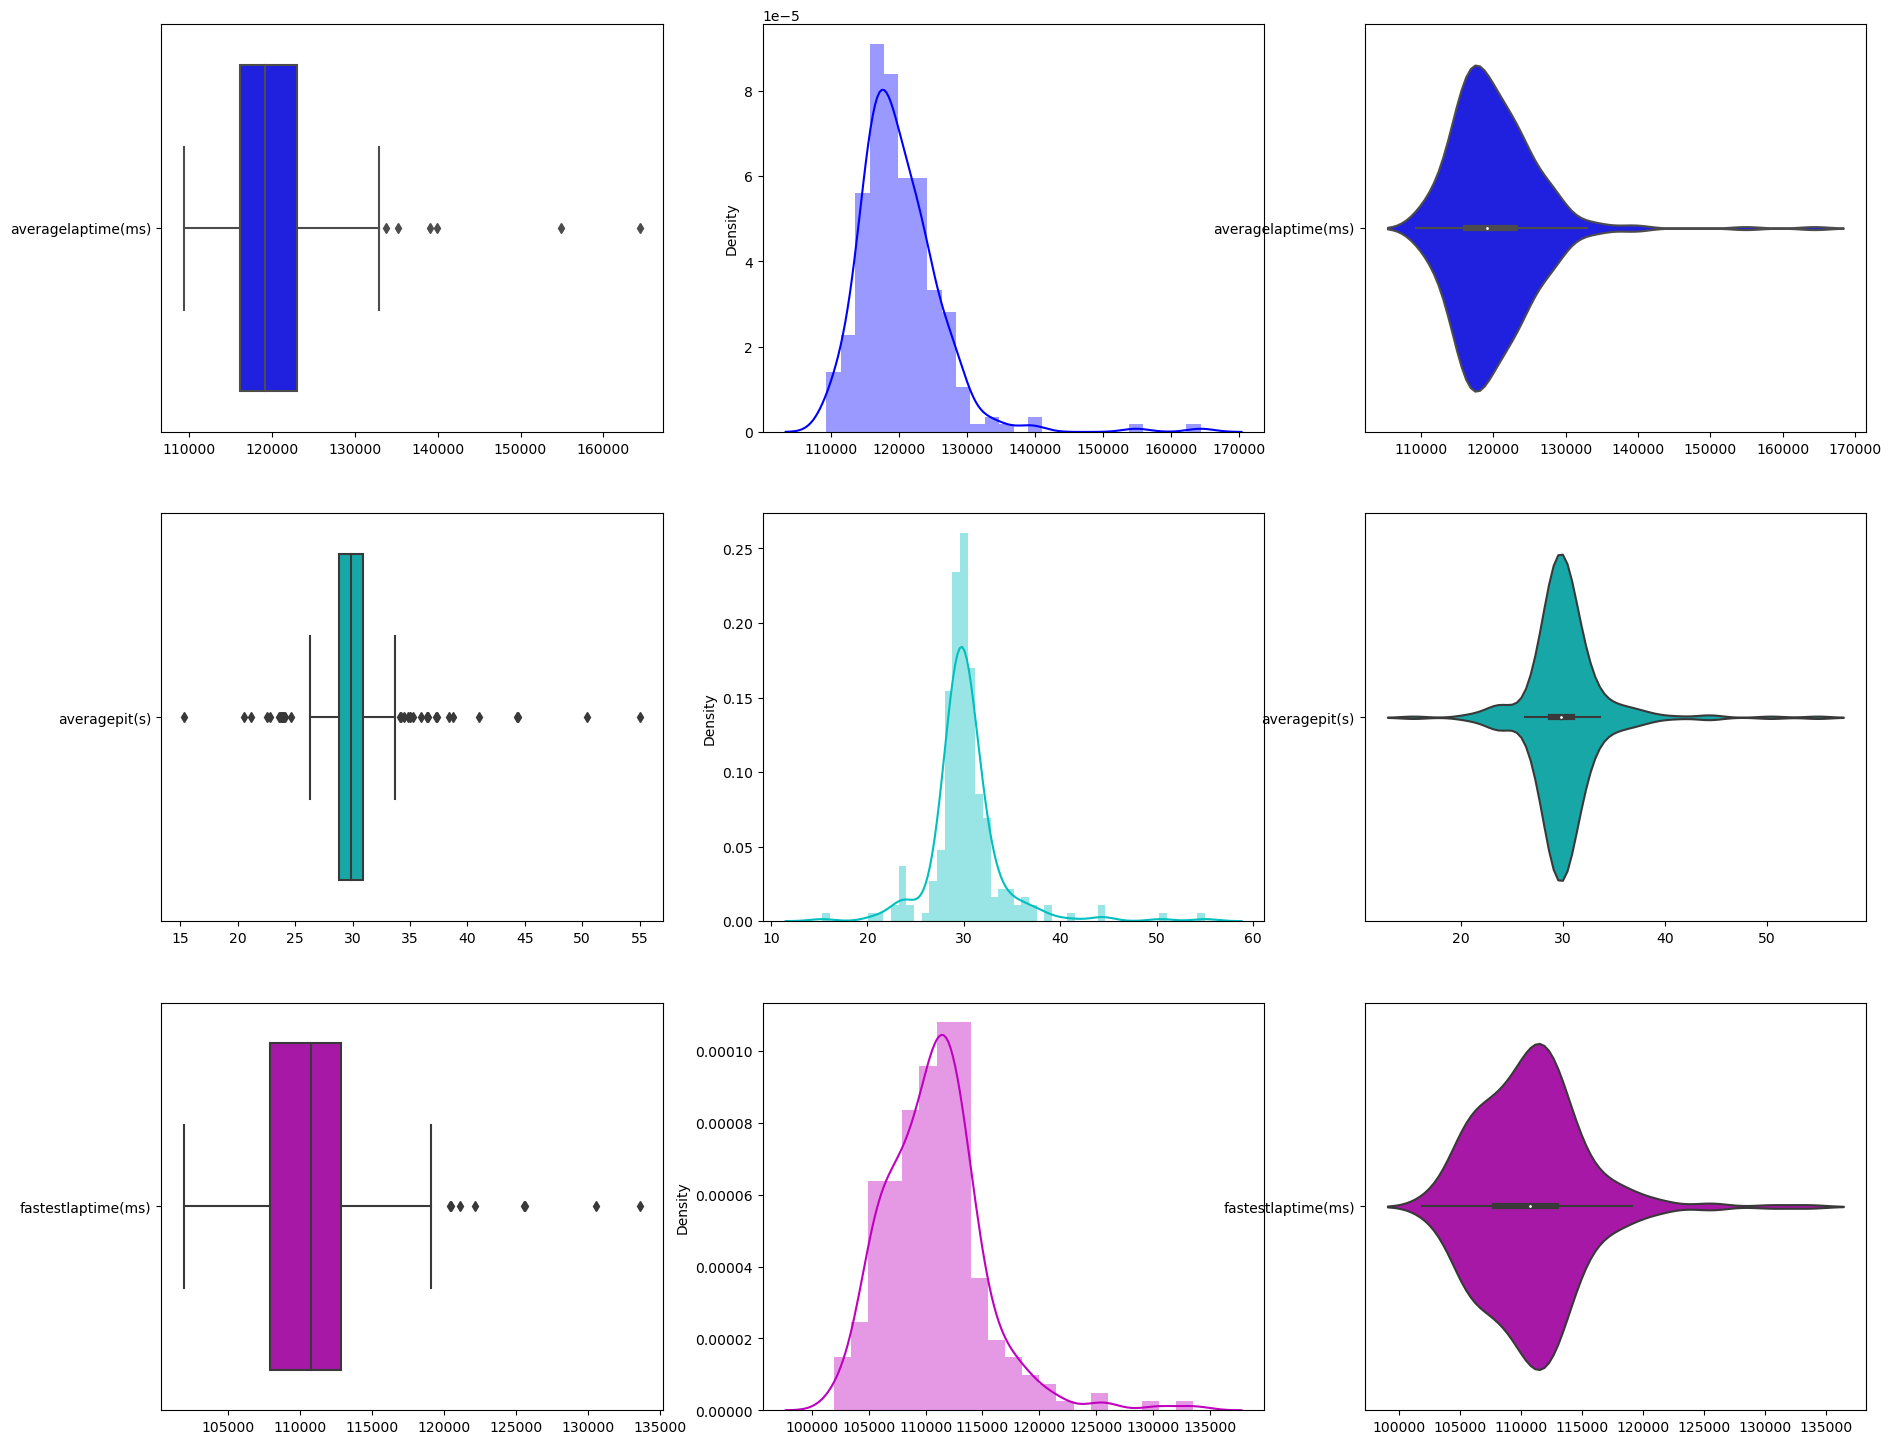

In [30]:
# uni-variate visualisation for timedf, pitdf and fastestdf

f, axes = plt.subplots(3, 3, figsize=(22,18))

# uni-variate visualisation for timedf eda

timedf_eda_uni = pd.DataFrame(timedf[["averagelaptime(ms)"]])
sb.boxplot(timedf_eda_uni, orient = "h", color = "b", ax = axes[0, 0]) # boxplot for averagelaptime
sb.distplot(timedf_eda_uni, kde = True, color = "b", ax = axes[0, 1]) # distplot for averagelaptime
sb.violinplot(timedf_eda_uni, orient = "h", color = "b", ax = axes[0, 2]) # violinplot for averagelaptime

# uni-variate visualisation for pitdf eda

pitdf_eda_uni = pd.DataFrame(pitdf[["averagepit(s)"]])
sb.boxplot(pitdf_eda_uni, orient = "h", color = "c", ax = axes[1, 0]) # boxplot for averagelaptime
sb.distplot(pitdf_eda_uni, kde = True, color = "c", ax = axes[1, 1]) # distplot for averagelaptime
sb.violinplot(pitdf_eda_uni, orient = "h", color = "c", ax = axes[1, 2]) # violinplot for averagelaptime

# uni-variate visualisation for fastestdf eda

fastestdf_eda_uni = pd.DataFrame(fastestdf[["fastestlaptime(ms)"]])
sb.boxplot(fastestdf_eda_uni, orient = "h", color = "m", ax = axes[2, 0]) # boxplot for averagelaptime
sb.distplot(fastestdf_eda_uni, kde = True, color = "m", ax = axes[2, 1]) # distplot for averagelaptime
sb.violinplot(fastestdf_eda_uni, orient = "h", color = "m", ax = axes[2, 2]) # violinplot for averagelaptime

Number of Grid Positions:  24
grid
1       13
2       13
3       13
4       13
5       13
6       13
7       13
8       13
9       13
10      13
11      13
12      13
13      13
14      13
15      13
16      13
17      13
18      13
19      13
20      13
21       6
22       6
23       3
24       3
Name: count, dtype: int64


/Users/adisontan/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


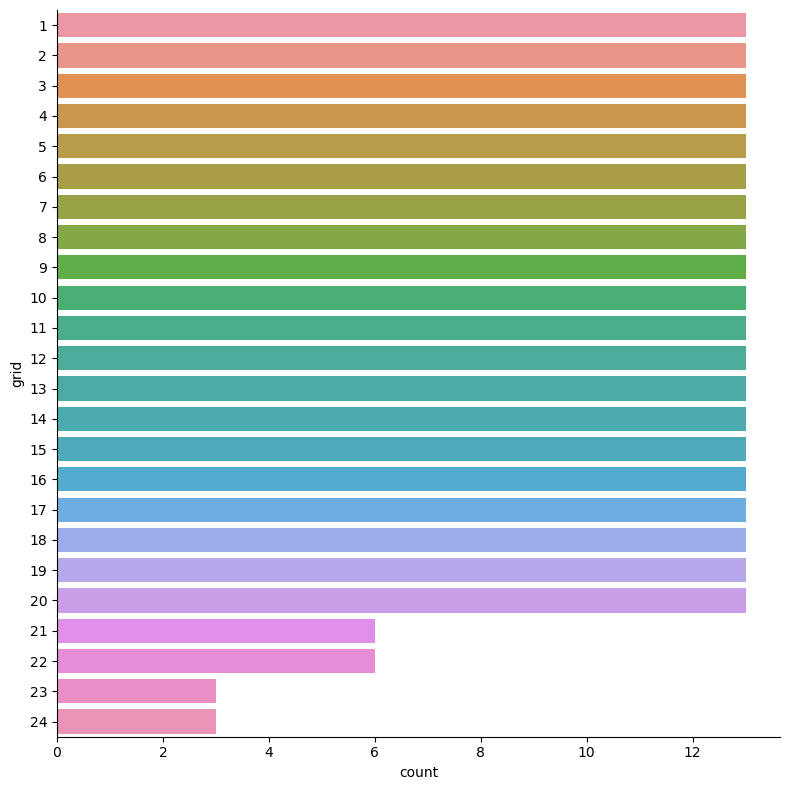

In [31]:
# uni-variate visualisation for griddf eda

griddf_eda_uni = pd.DataFrame(griddf[["grid"]])

# number of categories in the dataframe

print("Number of Grid Positions: ", len(griddf_eda_uni["grid"].unique()))

# frequencies of each category

print(griddf_eda_uni.value_counts().sort_index())
sb.catplot(y = "grid", data = griddf_eda_uni, kind = "count", height = 8) # 2010, 2011, 2012 has 24 drivers. 2013, 2014, 2016 has 22 drivers.

<Axes: xlabel='weather', ylabel='count'>

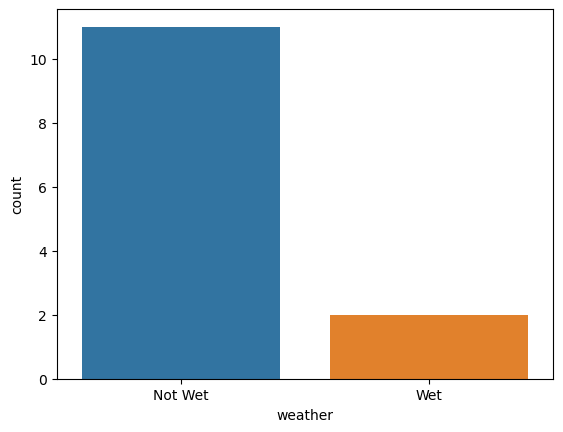

In [32]:
# uni-variate visualisation for weatherdf eda

sb.countplot(sgpweather, x="weather")

<br><br>
<span style="font-family: Courier New; font-size: 20px; font-weight: bold;">  
Bi-Variate Statistics Visualization // Exploratory Data Analysis
</span>
<br><br><br>

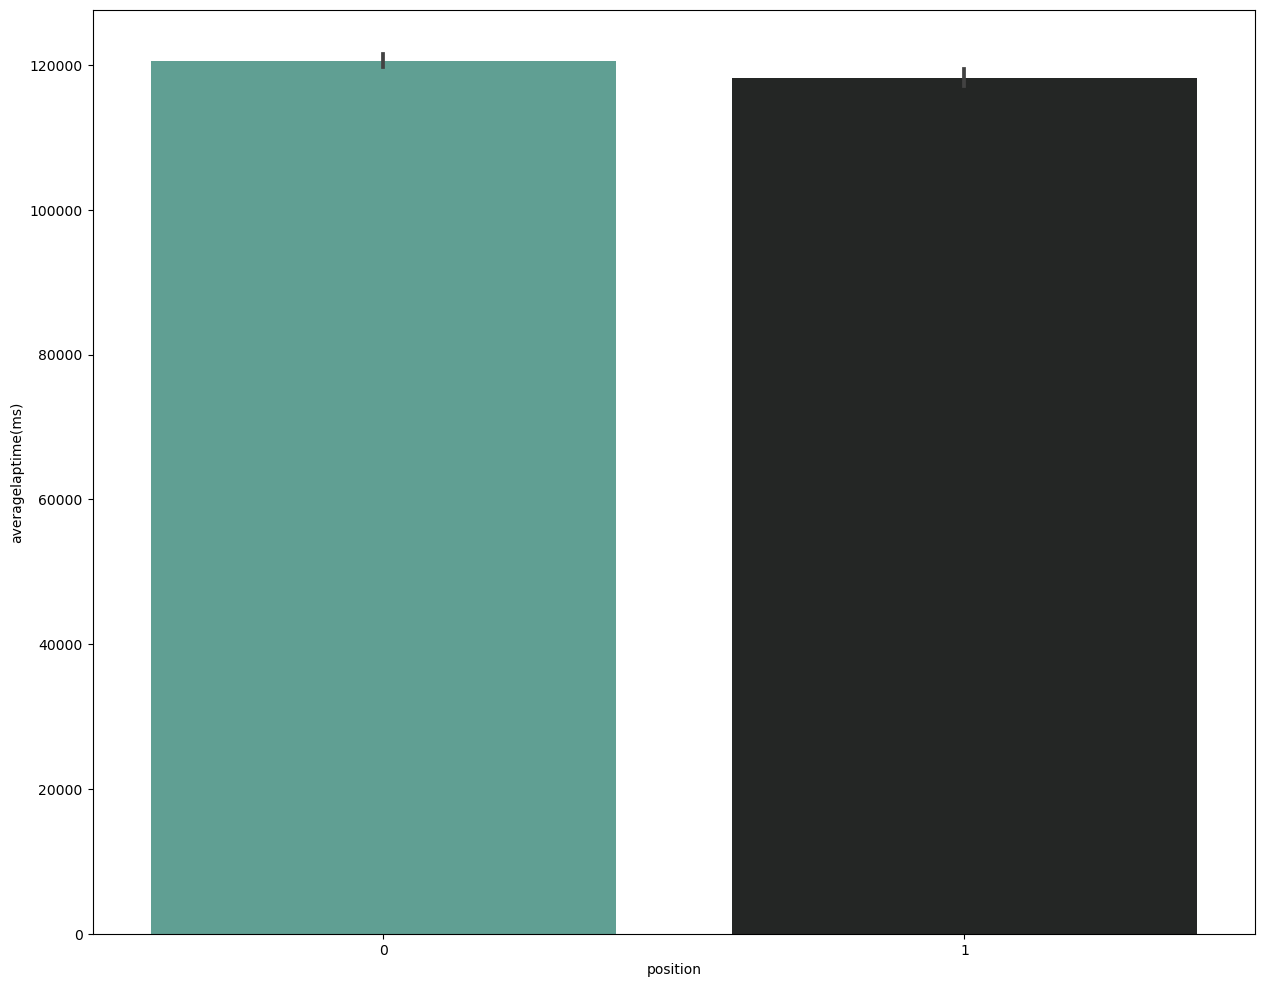

In [33]:
# barplot for timedf, averagelaptime(ms) vs position

plt.figure(figsize=(15, 12))
timedf_eda_uni2 = pd.DataFrame(timedf[["averagelaptime(ms)", "position"]])
sb.barplot(x = 'position', y = 'averagelaptime(ms)', data = timedf_eda_uni2, palette="dark:#5A9_r")
plt.show()

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_80166/19530208.py:4: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sb.catplot(data = pitdf, x = "position", y= "averagepit(s)", palette="dark:#5A9_r")
/Users/adisontan/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 1000x1000 with 0 Axes>

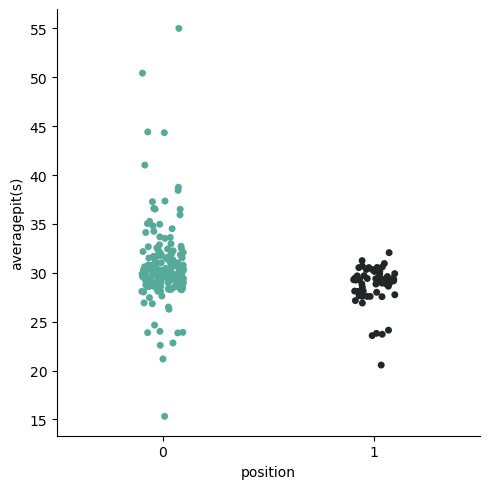

In [34]:
# catplot for pitdf, averagepit(s) vs position

f = plt.figure(figsize=(10, 10))
sb.catplot(data = pitdf, x = "position", y= "averagepit(s)", palette="dark:#5A9_r")

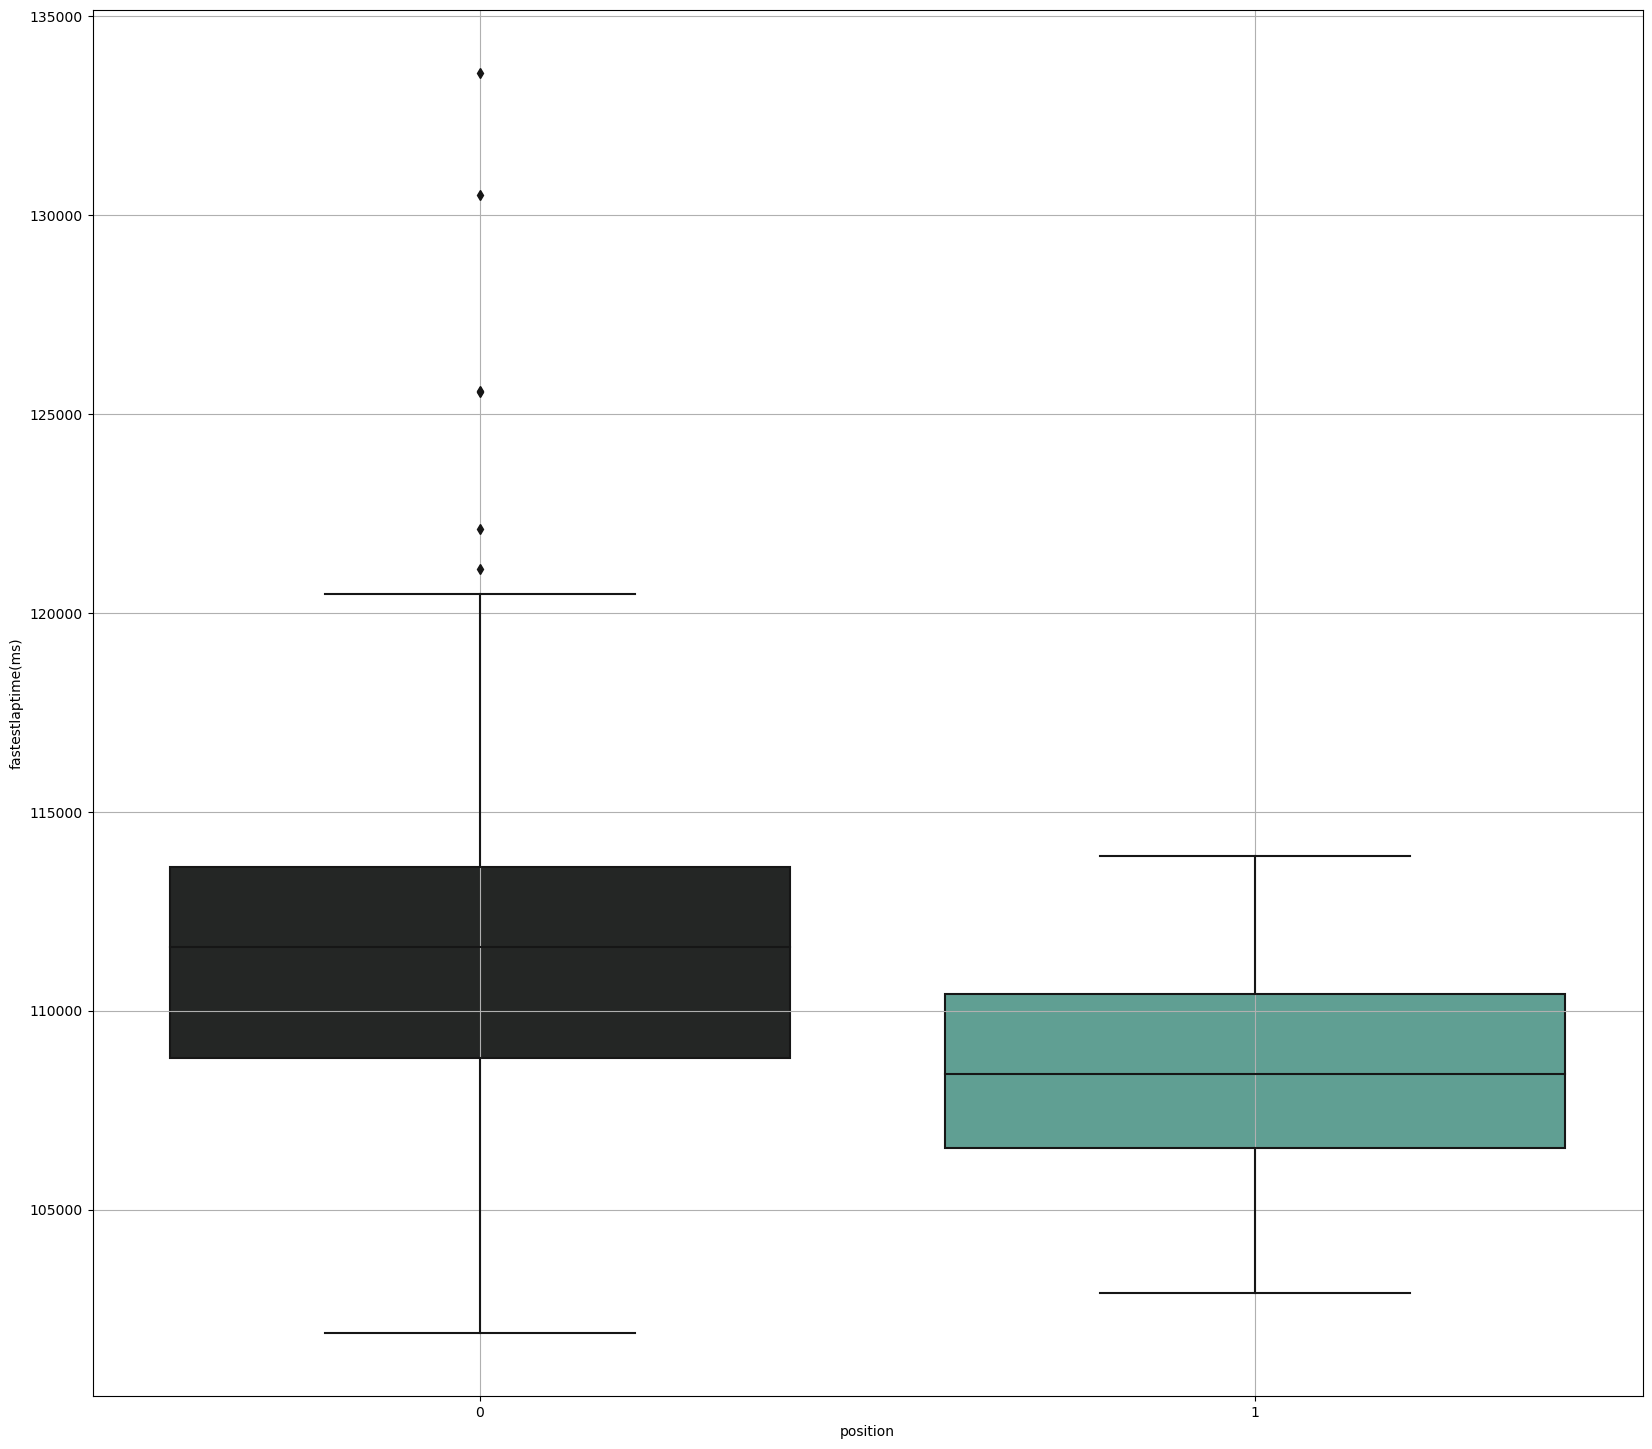

In [35]:
# boxplot for fastestdf, fastestlaptime(ms) vs Position

plt.figure(figsize=(20, 18))
timedf_eda_uni2 = sb.boxplot(y=fastestdf["fastestlaptime(ms)"], x=fastestdf["position"], width=0.8, palette="dark:#5A9")
plt.grid(True)
plt.show()

<Axes: xlabel='grid', ylabel='position'>

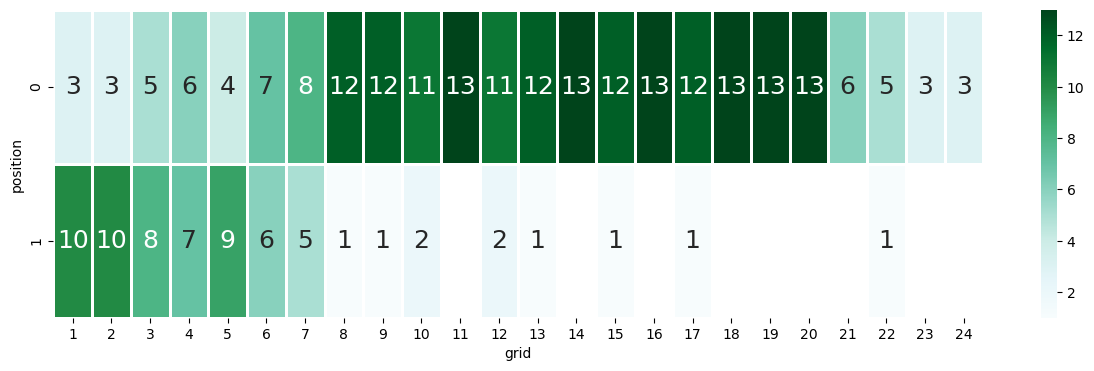

In [36]:
# heatmap for griddf, grid against position eda

f = plt.figure(figsize=(15, 4))
sb.heatmap(griddf.groupby(['position', 'grid']).size().unstack(), 
           linewidths = 1, annot = True, fmt = 'g', annot_kws = {"size": 18}, cmap = "BuGn")

<br><br>
<span style="font-family: Courier New; font-size: 18px; font-weight: bold;">  
Multi-Variate Statistics Visualization // Exploratory Data Analysis
</span>
<br><br><br>

In [37]:
# Creating mergedf dataset without the values we do not wish to see in the EDA

mergedf = pd.DataFrame(merge_df3[['averagepit(s)', 'averagelaptime(ms)', 'fastestlaptime(ms)', 'grid', 'position']])

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_80166/3202192651.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(mergedf[var], ax = axes[count,0])
/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_80166/3202192651.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(mergedf[

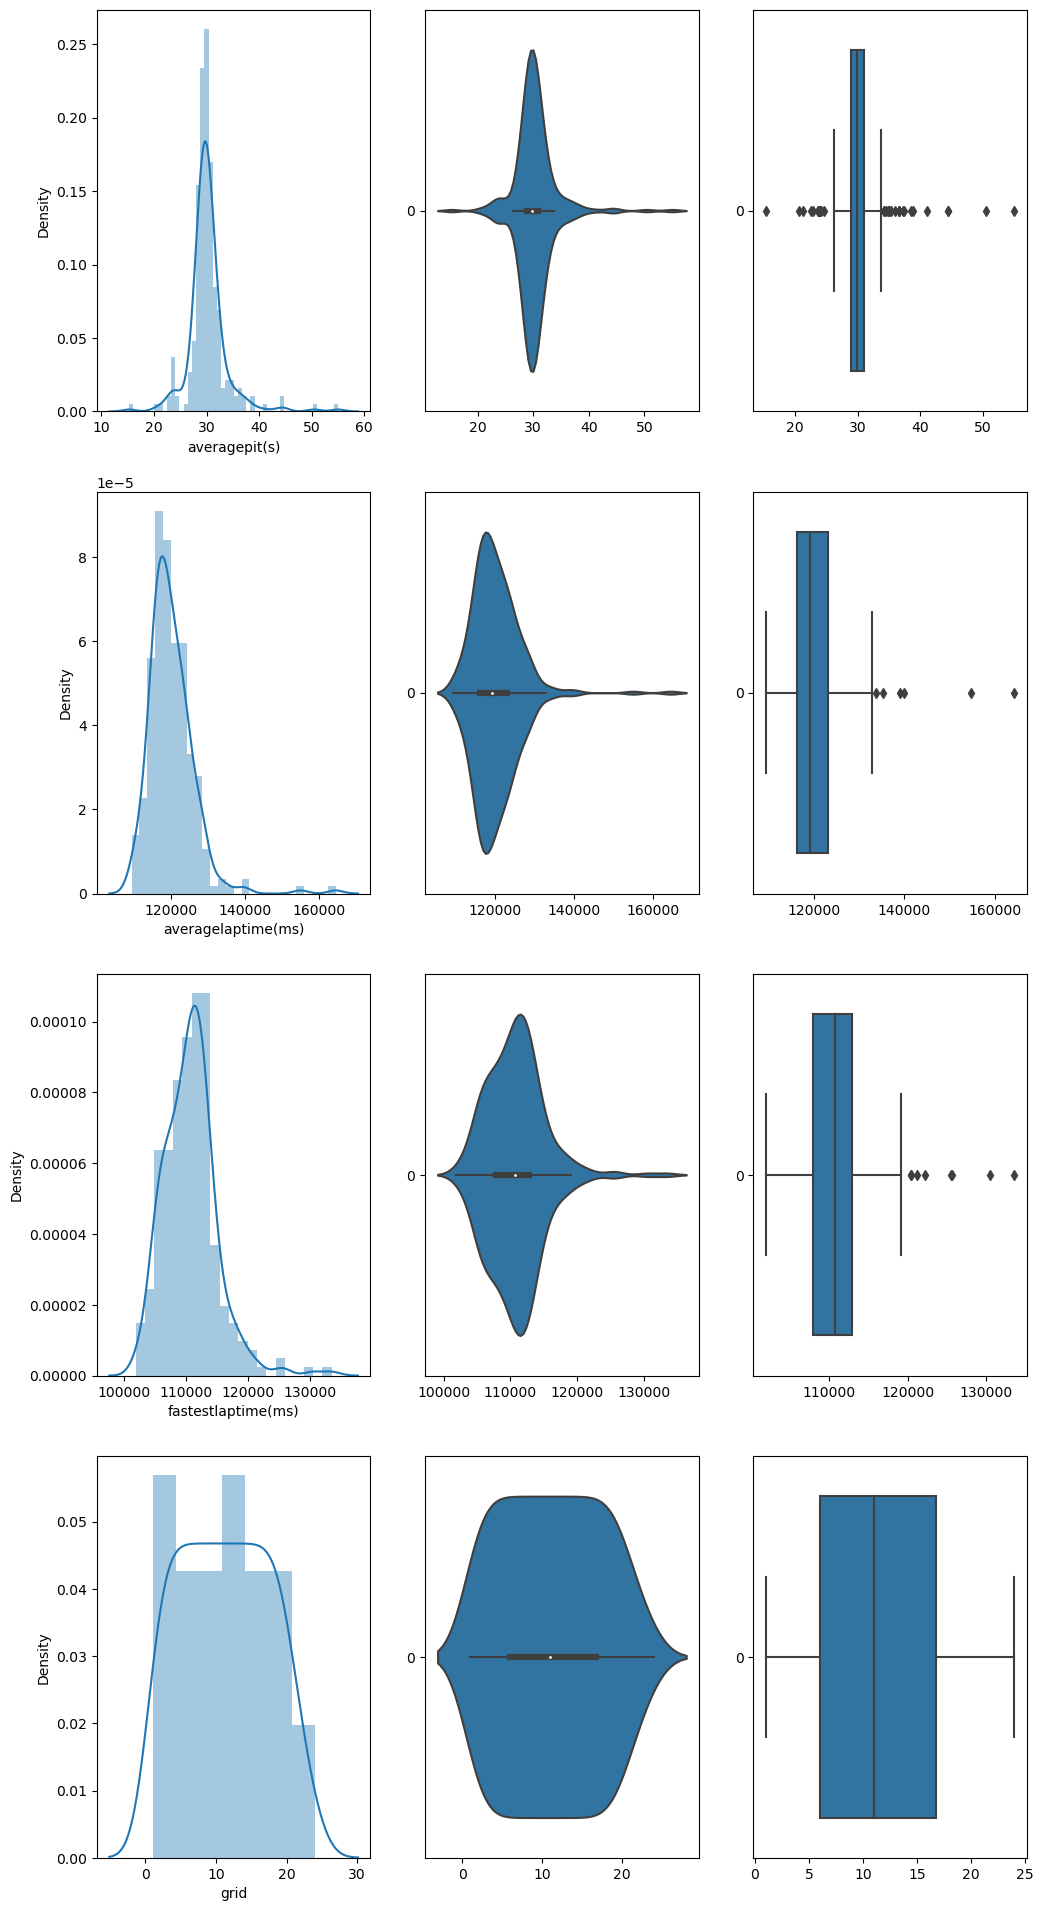

In [38]:
# distplot, violinplot, boxplot for mergedf

f, axes = plt.subplots(4, 3, figsize=(12,24))

count = 0 
for var in mergedf:
    if (count != 4):
        sb.distplot(mergedf[var], ax = axes[count,0]) 
        sb.violinplot(mergedf[var], ax = axes[count,1], orient = "h") 
        sb.boxplot(mergedf[var], ax = axes[count,2], orient = "h") 
        count += 1

/Users/adisontan/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


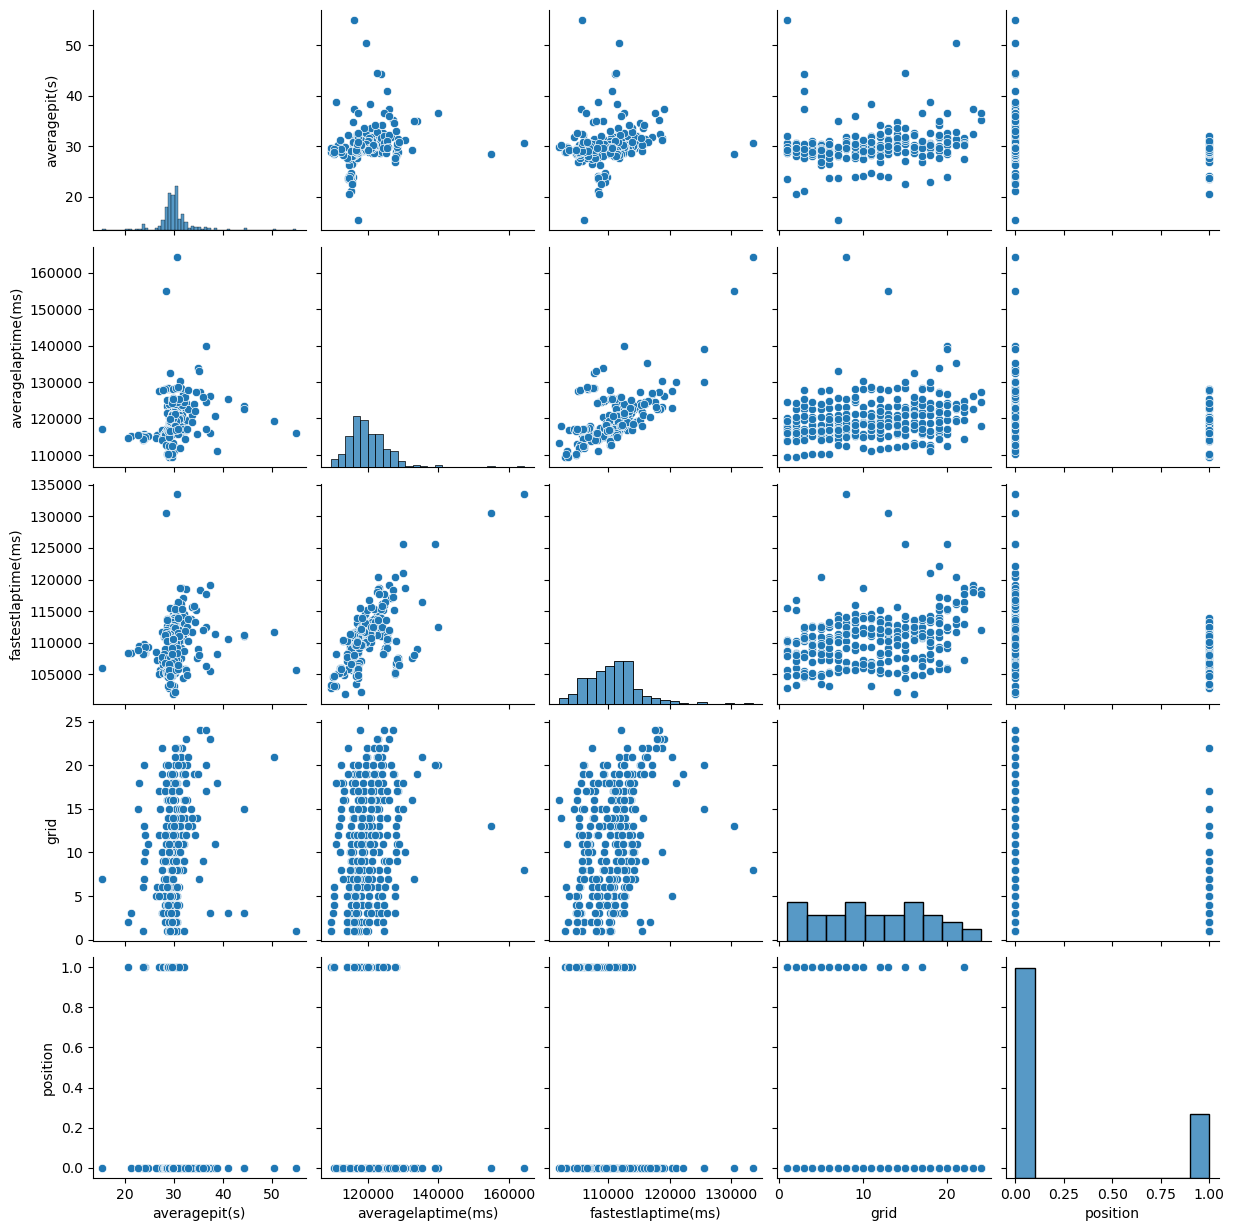

In [39]:
# pairplot for mergedf

sb.pairplot(data = mergedf)

<Axes: >

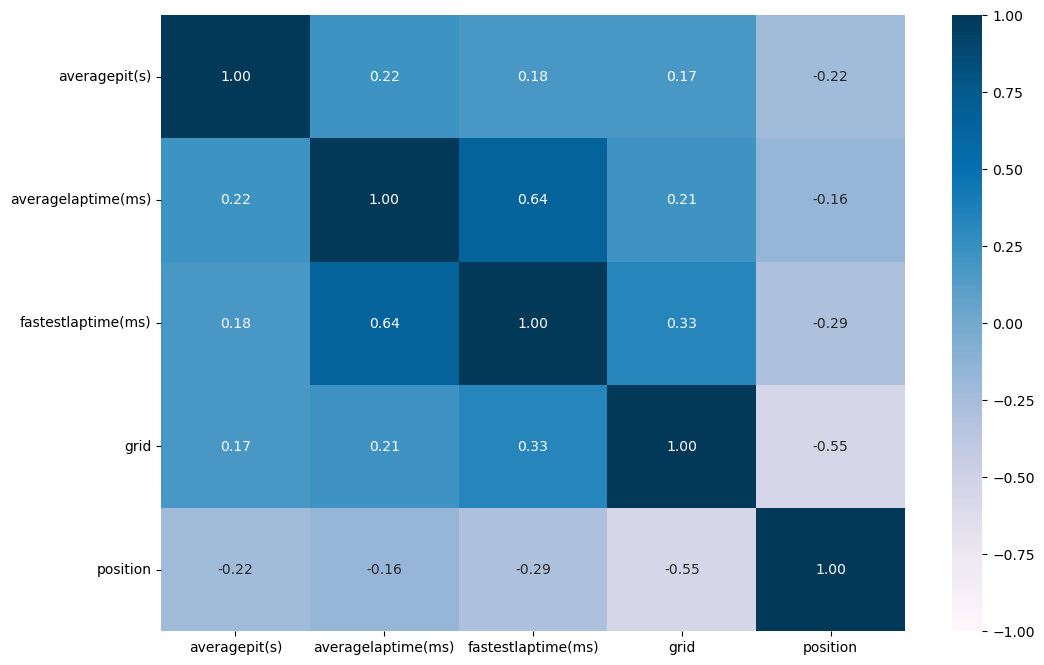

In [40]:
# heatmap for mergedf

f, axes = plt.subplots(1, 1, figsize=(12, 8))
sb.heatmap(mergedf.corr(), vmin = -1, vmax = 1, annot = True, fmt =".2f", cmap = "PuBu") # heatmap allowed us to differentiate the variables that we may have otherwised missed out in the corr matrix

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_80166/4202999352.py:3: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sb.catplot(data = weatherdf, x = "weather", y= "averagelaptime(ms)", palette="dark:#5A9_r")
/Users/adisontan/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


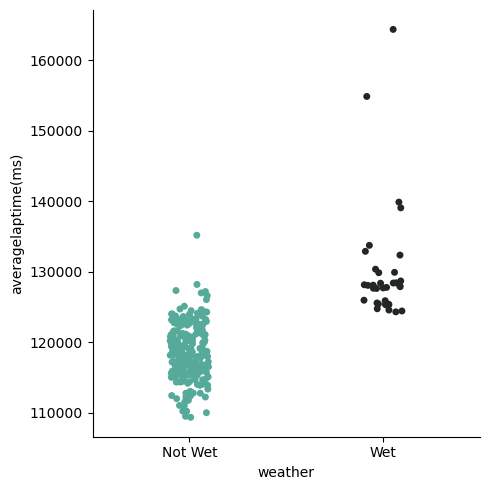

In [41]:
# catplot for weatherdf, weather against averagelaptime(ms)

sb.catplot(data = weatherdf, x = "weather", y= "averagelaptime(ms)", palette="dark:#5A9_r")

<Axes: xlabel='position', ylabel='count'>

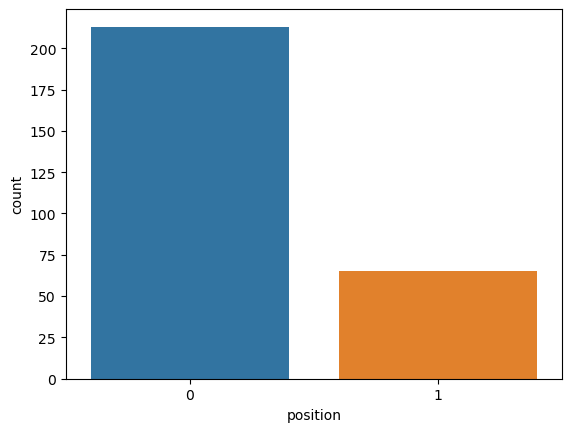

In [42]:
# imbalance in positions 0 and 1

sb.countplot(sgpresults, x="position")

In [46]:
# remove null values for model and merge single variables into one dataframe

mldf = mergedf.dropna(axis=0)

# change the position of the drivers to show top 5 , not top 5. 

mldf.loc[mldf['position'] == -1, 'position'] = 0
mldf['position'] = mldf['position'].astype(str).astype(int)
for i in mldf['position']:
    if (i >= 1 and i <= 5): 
        mldf.loc[mldf['position'] == i, 'position'] = 1 # set drivers who finish in top 5 to 1
    elif (i <= 0):
        continue
    elif (i > 5 and i <= 22):
        mldf[mldf['position'] == i, 'position'] = 0 # set drivers who finish outside of top 5 to 0

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_80166/2906951859.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mldf['position'] = mldf['position'].astype(str).astype(int)


<span style="font-family: Courier New; font-size: 20px; font-weight: bold;">  
UPSAMPLING
</span>
<br><br><br>

position
0    177
1    177
Name: count, dtype: int64


<Axes: xlabel='position', ylabel='count'>

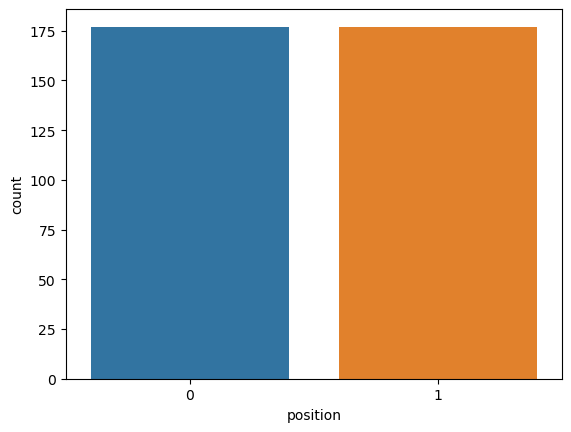

In [47]:
# Upsample Top 5 to meet Not Top 5 due to huge class imbalance

from sklearn.utils import resample

top5 = mldf[mldf.position == 1]
nottop5 = mldf[mldf.position == 0]
 
# sample the Top 5 samples
top5_up = resample(top5, 
                        replace=True,                     
                        n_samples=nottop5.shape[0])    
 
# combine the two classes back after upsampling
mldf_up = pd.concat([nottop5, top5_up])
 
# check the ratio of the classes
print(mldf_up['position'].value_counts())

# quick plot to check the balanced classes visually
sb.countplot(mldf_up, x="position")

In [48]:
# defining predictor and response variables for ML with upsampling

mldf_up_pred = mldf_up.drop('position', axis = 1)
mldf_up_res = mldf_up['position']
print(mldf_up_pred.info())
print()
print(mldf_up_res.info())

<class 'pandas.core.frame.DataFrame'>
Index: 354 entries, 0 to 183
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   averagepit(s)       354 non-null    float64
 1   averagelaptime(ms)  354 non-null    float64
 2   fastestlaptime(ms)  354 non-null    float64
 3   grid                354 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 13.8 KB
None

<class 'pandas.core.series.Series'>
Index: 354 entries, 0 to 183
Series name: position
Non-Null Count  Dtype
--------------  -----
354 non-null    int64
dtypes: int64(1)
memory usage: 5.5 KB
None


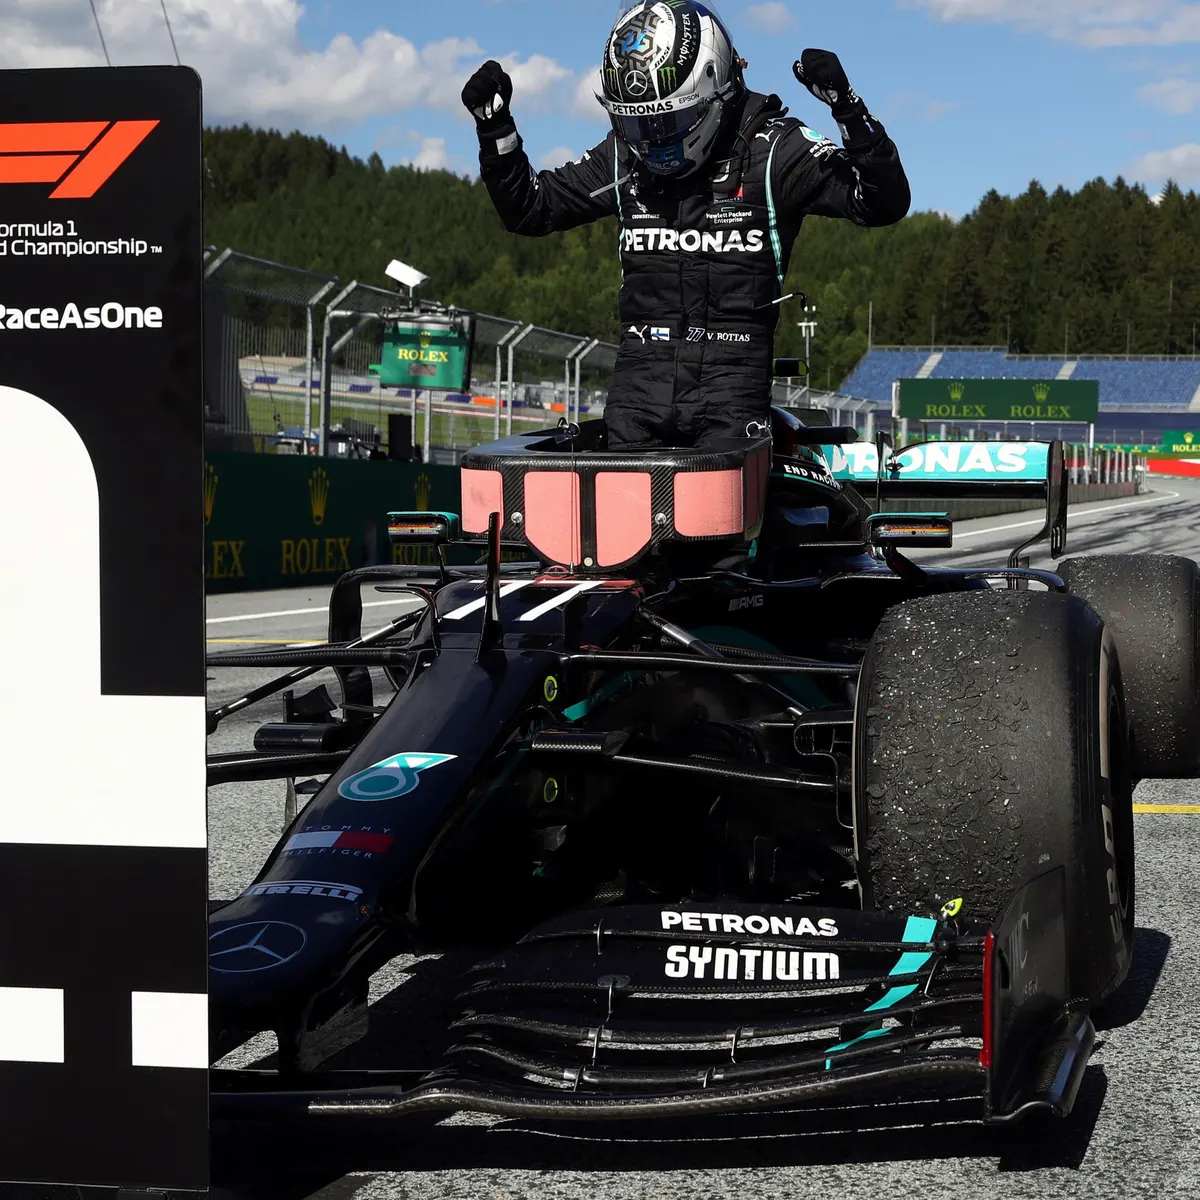

<br><br>
<span style="font-family: Courier New; font-size: 30px; font-weight: bold;">  
MACHINE LEARNING MODELS
</span>
<br>

<br>
<span style="font-family: Courier New; font-size: 20px; font-weight: bold;">  
UNI-VARIATE CLASSIFICATION TREE // MACHINE LEARNING
</span>
<br><br><br>

In [49]:
# function defintion for calculating tp, tn, fp and fn rates

def rate(num, den):
    rate = num/(num+den)
    return rate

In [50]:
# extract uni-variables for uni-variate classification tree

pos_ml = pd.DataFrame(mldf_up[['position']])
time_ml = pd.DataFrame(mldf_up[['averagelaptime(ms)']])
pit_ml = pd.DataFrame(mldf_up[['averagepit(s)']])
fastest_ml = pd.DataFrame(mldf_up[['fastestlaptime(ms)']])
grid_ml =  pd.DataFrame(mldf_up[['grid']])

In [51]:
from sklearn.metrics import confusion_matrix 

# function definition for classification tree model

def classtreemodel(preddf, respdf, depth, confuse, tree, testsize, cv = 10): # function depth is for depth of tree, tree is to decide if you want to print tree together with metrics, test size is to decide train:test
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.model_selection import train_test_split
    from sklearn.tree import plot_tree
    from sklearn.model_selection import cross_val_score
    
    X_train, X_test, y_train, y_test = train_test_split(preddf, respdf, test_size = testsize)

    # Decision Tree using Train Data
    dectree = DecisionTreeClassifier(max_depth = depth)  # create the decision tree object
    dectree.fit(X_train, y_train)                    # train the decision tree model

    # Calculate cross-validation score
    cv_scores = cross_val_score(dectree, preddf, respdf, cv=cv)
    
    # Print cross-validation score
    print("Cross-Validation Scores:", cv_scores)
    print("Mean Accuracy:", np.mean(cv_scores))
    print()
    
    # Predict Response corresponding to Predictors
    y_train_pred = dectree.predict(X_train)
    y_test_pred = dectree.predict(X_test)
    
    if (confuse == True):
        f, axes = plt.subplots(1, 2, figsize=(12, 4))
        sb.heatmap(confusion_matrix(y_train, y_train_pred),
                   annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0], cmap="PuBu")
        sb.heatmap(confusion_matrix(y_test, y_test_pred), 
                   annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1], cmap="PuBu")
    
    if (tree == True):
        f = plt.figure(figsize=(23,10))
        plot_tree(dectree, filled=True, rounded=True, 
                  feature_names=X_train.columns.tolist(), 
                  class_names=['Not Top 5','Top 5'])
        
        tntrain, fptrain, fntrain, tptrain = confusion_matrix(y_train, y_train_pred).ravel()
        tntest, fptest, fntest, tptest = confusion_matrix(y_test, y_test_pred).ravel()

        print("\t\t Train Dataset")
        print("Classification Accuracy\t\t:", dectree.score(X_train, y_train))
        print()

        print("\t\t Test Dataset")
        print("Classification Accuracy\t\t:", dectree.score(X_test, y_test))
        print()

        print("\t\t Train Dataset")
        print("True Positive Rate\t\t:", rate(tptrain, fntrain))
        print()

        print("\t\t Test Dataset")
        print("True Positive Rate\t\t:", rate(tptest, fntest))
        print()

        print("\t\t Train Dataset")
        print("True Negative Rate\t\t:", rate(tntrain, fptrain))
        print()

        print("\t\t Test Dataset")
        print("True Negative Rate\t\t:", rate(tntest, fptest))
        print()

        print("\t\t Train Dataset")
        print("False Positive Rate\t\t:", rate(fptrain, tntrain))
        print()

        print("\t\t Test Dataset")
        print("False Positive Rate\t\t:", rate(fptest, tntest))
        print()

        print("\t\t Train Dataset")
        print("False Negative Rate\t\t:", rate(fntrain, tptrain))
        print()

        print("\t\t Test Dataset")
        print("False Negative Rate\t\t:", rate(fntest, tptest))
        print()

Cross-Validation Scores: [0.72222222 0.77777778 0.61111111 0.69444444 0.74285714 0.62857143
 0.42857143 0.68571429 0.6        0.6       ]
Mean Accuracy: 0.649126984126984

		 Train Dataset
Classification Accuracy		: 0.7509433962264151

		 Test Dataset
Classification Accuracy		: 0.7078651685393258

		 Train Dataset
True Positive Rate		: 0.5190839694656488

		 Test Dataset
True Positive Rate		: 0.5

		 Train Dataset
True Negative Rate		: 0.9776119402985075

		 Test Dataset
True Negative Rate		: 0.9302325581395349

		 Train Dataset
False Positive Rate		: 0.022388059701492536

		 Test Dataset
False Positive Rate		: 0.06976744186046512

		 Train Dataset
False Negative Rate		: 0.48091603053435117

		 Test Dataset
False Negative Rate		: 0.5



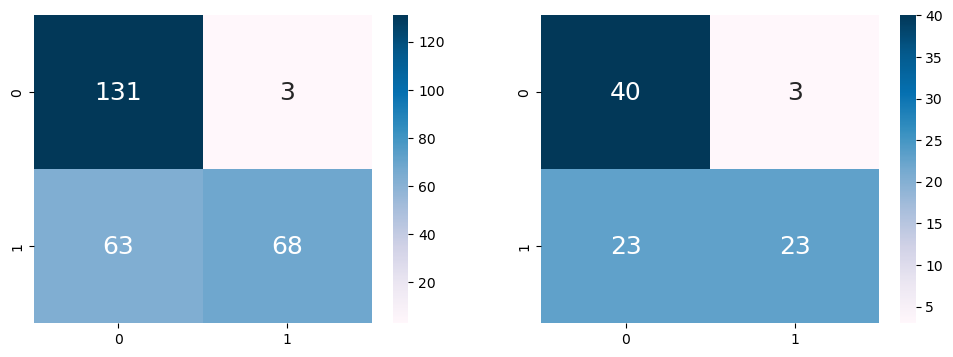

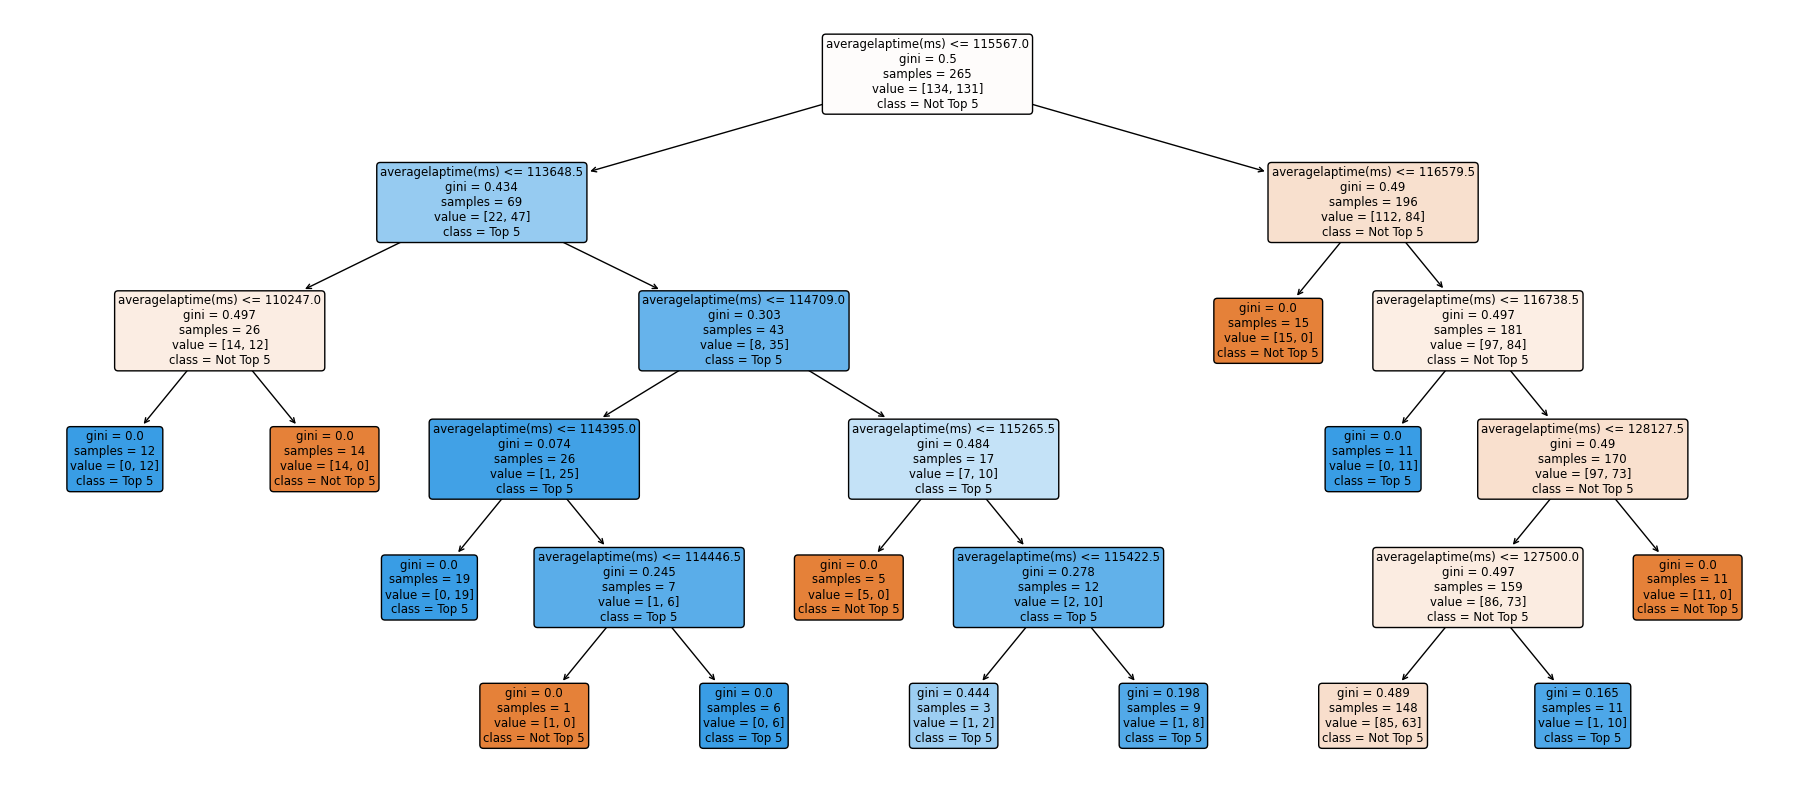

In [52]:
# classification tree for timedf vs position

classtreemodel(time_ml, pos_ml, 5, True, True, 0.25) # we define we want depth of 4, we want the class tree, we want the confusion matrix and we want a train:test ratio of 0.25

Cross-Validation Scores: [0.66666667 0.86111111 0.75       0.75       0.74285714 0.74285714
 0.51428571 0.71428571 0.68571429 0.82857143]
Mean Accuracy: 0.7256349206349206

		 Train Dataset
Classification Accuracy		: 0.7660377358490567

		 Test Dataset
Classification Accuracy		: 0.7191011235955056

		 Train Dataset
True Positive Rate		: 0.835820895522388

		 Test Dataset
True Positive Rate		: 0.813953488372093

		 Train Dataset
True Negative Rate		: 0.6946564885496184

		 Test Dataset
True Negative Rate		: 0.6304347826086957

		 Train Dataset
False Positive Rate		: 0.3053435114503817

		 Test Dataset
False Positive Rate		: 0.3695652173913043

		 Train Dataset
False Negative Rate		: 0.16417910447761194

		 Test Dataset
False Negative Rate		: 0.18604651162790697



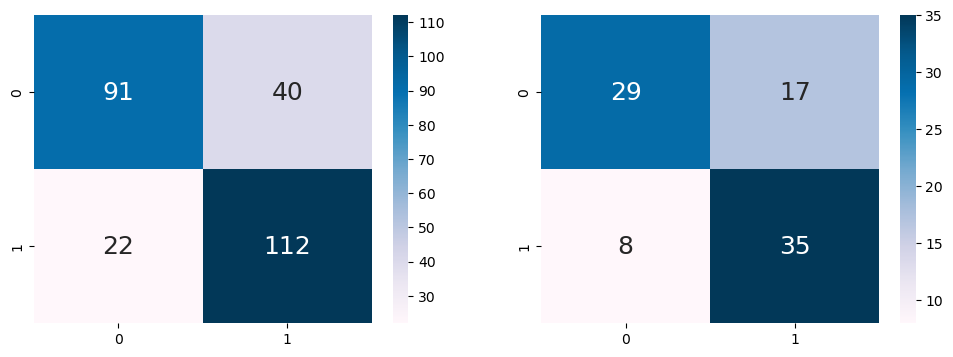

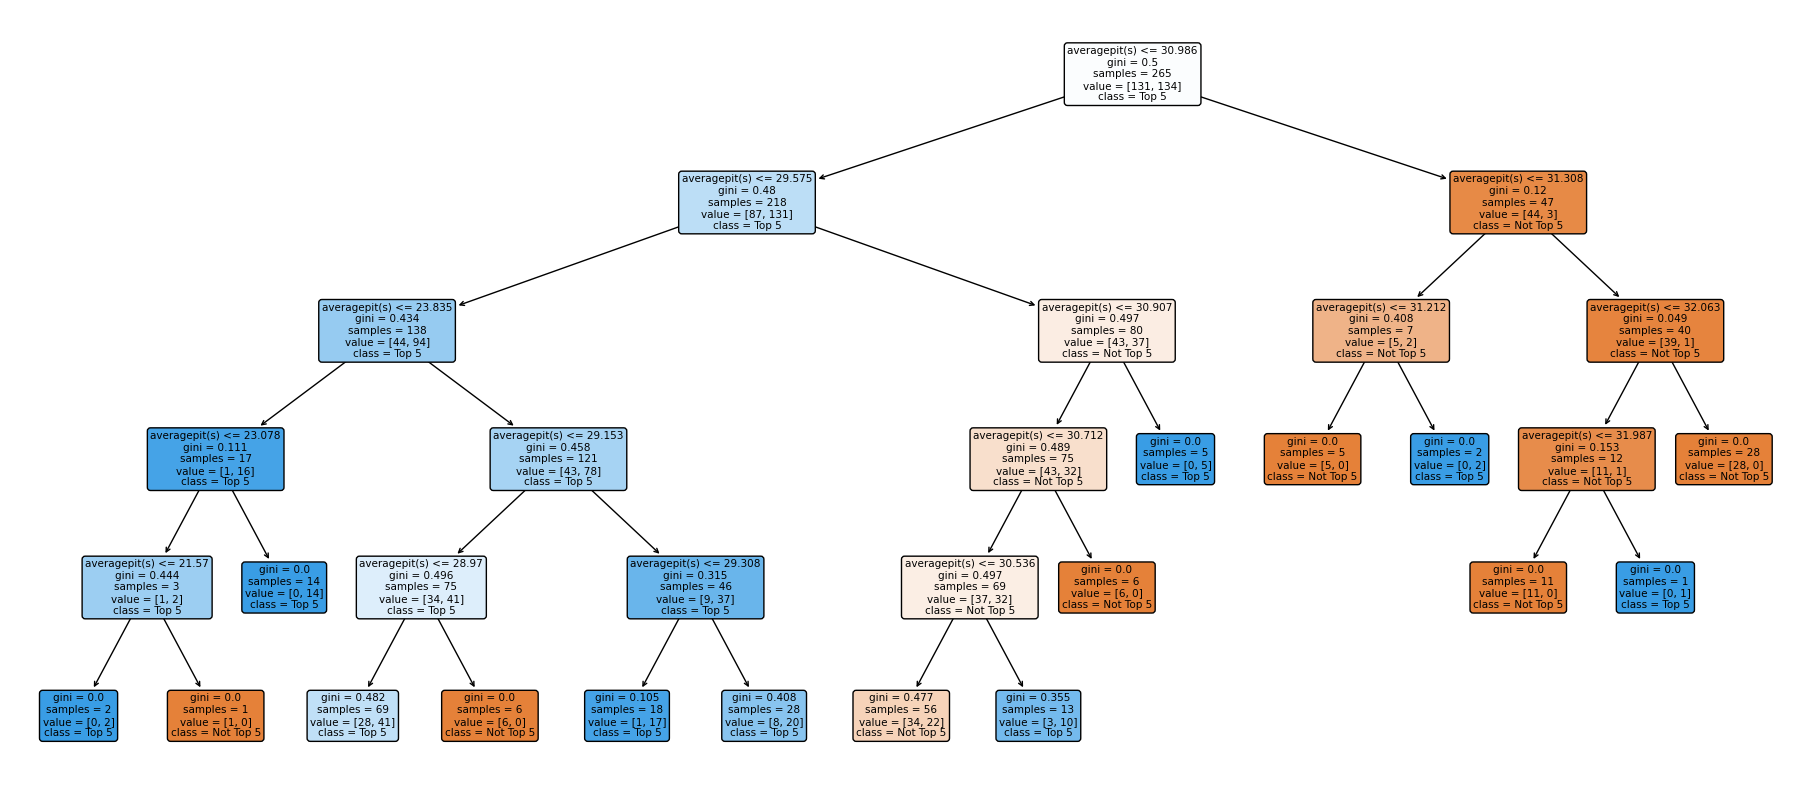

In [53]:
# classification tree for pitdf vs position

classtreemodel(pit_ml, pos_ml, 5, True, True, 0.25) # we define we want depth of 5, we want the class tree, we want the confusion matrix and we want a train:test ratio of 0.25

Cross-Validation Scores: [0.66666667 0.80555556 0.86111111 0.83333333 0.74285714 0.77142857
 0.6        0.65714286 0.57142857 0.71428571]
Mean Accuracy: 0.7223809523809523

		 Train Dataset
Classification Accuracy		: 0.8113207547169812

		 Test Dataset
Classification Accuracy		: 0.7191011235955056

		 Train Dataset
True Positive Rate		: 0.9621212121212122

		 Test Dataset
True Positive Rate		: 0.8222222222222222

		 Train Dataset
True Negative Rate		: 0.6616541353383458

		 Test Dataset
True Negative Rate		: 0.6136363636363636

		 Train Dataset
False Positive Rate		: 0.3383458646616541

		 Test Dataset
False Positive Rate		: 0.38636363636363635

		 Train Dataset
False Negative Rate		: 0.03787878787878788

		 Test Dataset
False Negative Rate		: 0.17777777777777778



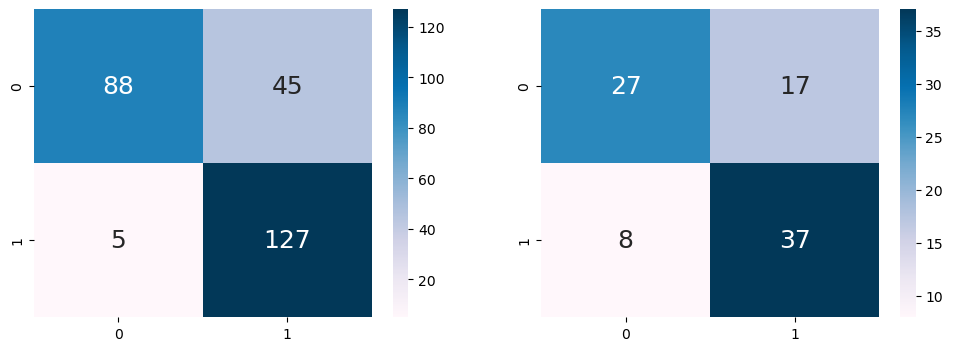

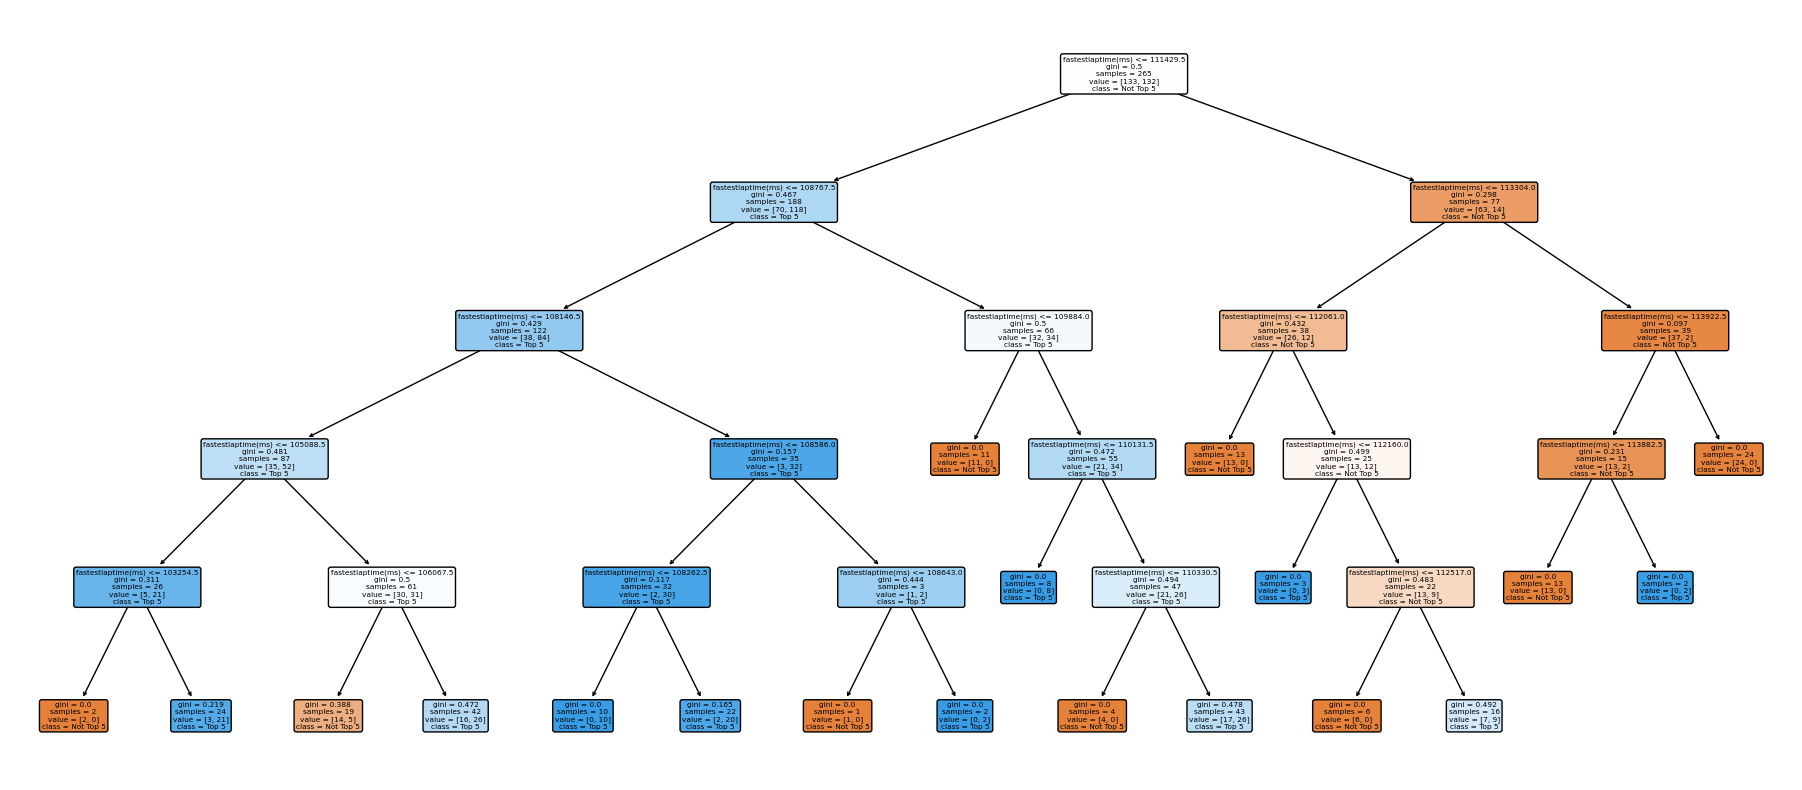

In [54]:
# classification tree for fastestdf vs position

classtreemodel(fastest_ml, pos_ml, 5, True, True, 0.25) # we define we want depth of 5, we want the class tree, we want the confusion matrix and we want a train:test ratio of 0.25

Cross-Validation Scores: [0.69444444 0.83333333 0.91666667 0.83333333 0.74285714 0.94285714
 0.82857143 0.88571429 0.88571429 0.8       ]
Mean Accuracy: 0.8363492063492064

		 Train Dataset
Classification Accuracy		: 0.8377358490566038

		 Test Dataset
Classification Accuracy		: 0.8426966292134831

		 Train Dataset
True Positive Rate		: 0.8548387096774194

		 Test Dataset
True Positive Rate		: 0.8113207547169812

		 Train Dataset
True Negative Rate		: 0.8226950354609929

		 Test Dataset
True Negative Rate		: 0.8888888888888888

		 Train Dataset
False Positive Rate		: 0.1773049645390071

		 Test Dataset
False Positive Rate		: 0.1111111111111111

		 Train Dataset
False Negative Rate		: 0.14516129032258066

		 Test Dataset
False Negative Rate		: 0.18867924528301888



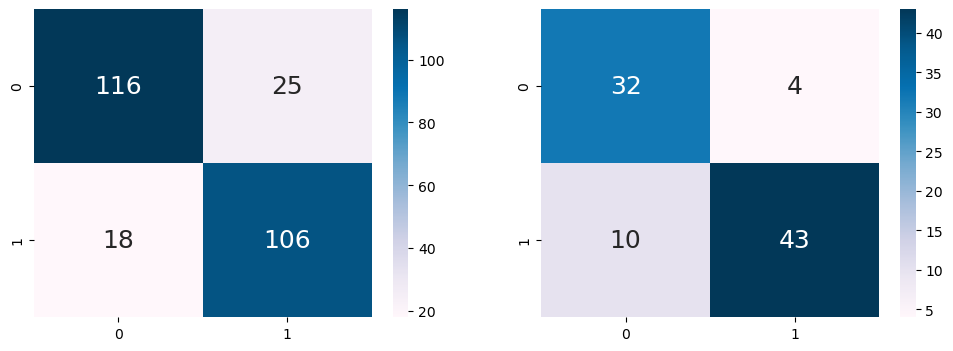

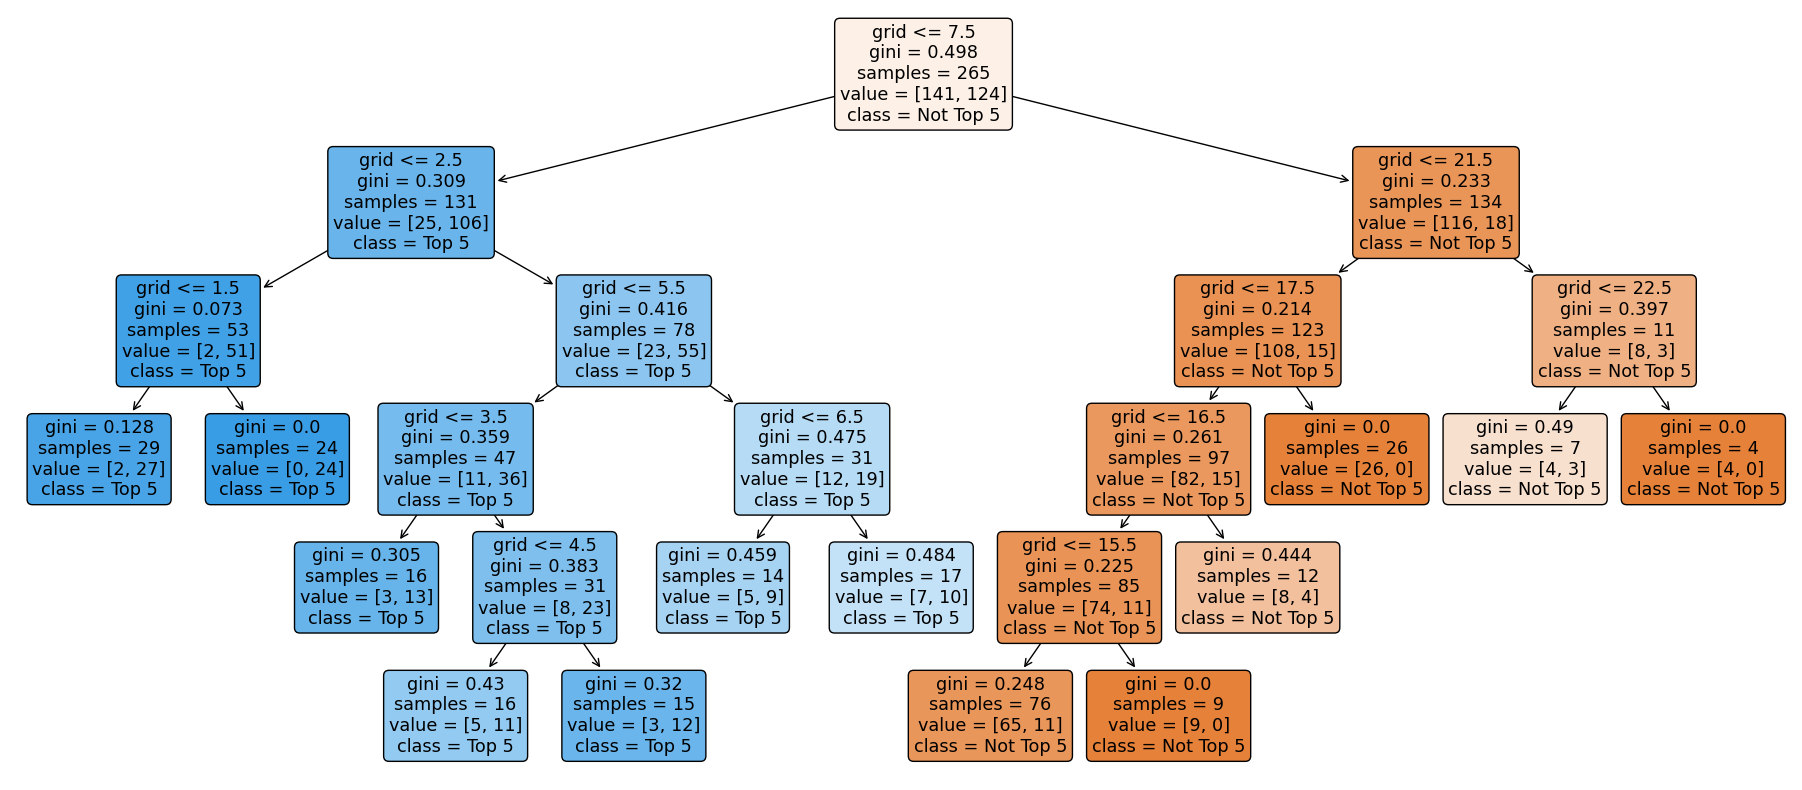

In [55]:
# classification tree for griddf vs position

classtreemodel(grid_ml, pos_ml, 5, True, True, 0.25) # we define we want depth of 4, we want the class tree, we want the confusion matrix and we want a train:test ratio of 0.25

<br><br><br>
<span style="font-family: Courier New; font-size: 20px; font-weight: bold;">  
MULTI-VARIATE CLASSIFICATION TREE // MACHINE LEARNING
</span>
<br><br><br>

Cross-Validation Scores: [0.69444444 0.77777778 0.91666667 0.94444444 0.85714286 0.91428571
 0.82857143 0.85714286 0.91428571 0.8       ]
Mean Accuracy: 0.8504761904761906

		 Train Dataset
Classification Accuracy		: 0.9320754716981132

		 Test Dataset
Classification Accuracy		: 0.8876404494382022

		 Train Dataset
True Positive Rate		: 0.9714285714285714

		 Test Dataset
True Positive Rate		: 0.9459459459459459

		 Train Dataset
True Negative Rate		: 0.888

		 Test Dataset
True Negative Rate		: 0.8461538461538461

		 Train Dataset
False Positive Rate		: 0.112

		 Test Dataset
False Positive Rate		: 0.15384615384615385

		 Train Dataset
False Negative Rate		: 0.02857142857142857

		 Test Dataset
False Negative Rate		: 0.05405405405405406



<Axes: >

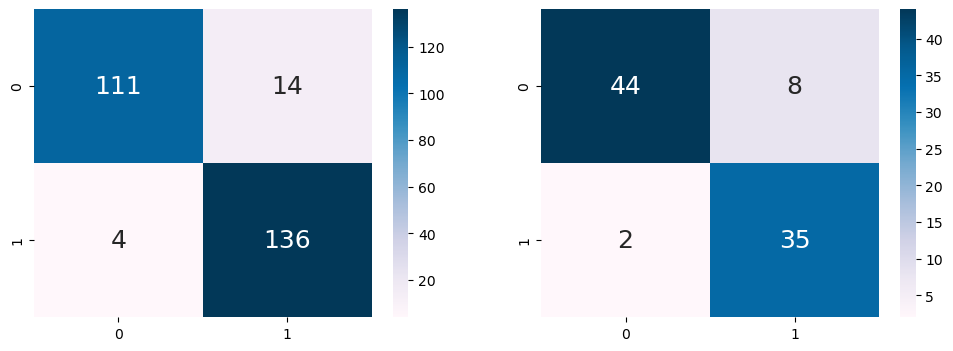

In [56]:
# Import essential models and functions from sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score

# Extract Response and Predictors
predictors = ["averagepit(s)", "fastestlaptime(ms)", "averagelaptime(ms)", "grid"]

y = pd.DataFrame(mldf_up['position'])
X = pd.DataFrame(mldf_up[predictors]) 

# Split the Dataset into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

# Decision Tree using Train Data
dectree = DecisionTreeClassifier(max_depth = 5)  # create the decision tree object
dectree.fit(X_train, y_train)                    # train the decision tree model

    
# Calculate cross-validation score
cv_scores = cross_val_score(dectree, X, y, cv=10)
    
# Print cross-validation score
print("Cross-Validation Scores:", cv_scores)
print("Mean Accuracy:", np.mean(cv_scores))
print()

# Predict Response corresponding to Predictors
y_train_pred = dectree.predict(X_train)
y_test_pred = dectree.predict(X_test)

tntrain, fptrain, fntrain, tptrain = confusion_matrix(y_train, y_train_pred).ravel()
tntest, fptest, fntest, tptest = confusion_matrix(y_test, y_test_pred).ravel()

print("\t\t Train Dataset")
print("Classification Accuracy\t\t:", dectree.score(X_train, y_train))
print()

print("\t\t Test Dataset")
print("Classification Accuracy\t\t:", dectree.score(X_test, y_test))
print()

print("\t\t Train Dataset")
print("True Positive Rate\t\t:", rate(tptrain, fntrain))
print()

print("\t\t Test Dataset")
print("True Positive Rate\t\t:", rate(tptest, fntest))
print()

print("\t\t Train Dataset")
print("True Negative Rate\t\t:", rate(tntrain, fptrain))
print()

print("\t\t Test Dataset")
print("True Negative Rate\t\t:", rate(tntest, fptest))
print()

print("\t\t Train Dataset")
print("False Positive Rate\t\t:", rate(fptrain, tntrain))
print()

print("\t\t Test Dataset")
print("False Positive Rate\t\t:", rate(fptest, tntest))
print()

print("\t\t Train Dataset")
print("False Negative Rate\t\t:", rate(fntrain, tptrain))
print()

print("\t\t Test Dataset")
print("False Negative Rate\t\t:", rate(fntest, tptest))
print()

# Plot the Confusion Matrix for Train and Test
f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(y_train, y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0], cmap="PuBu")
sb.heatmap(confusion_matrix(y_test, y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1], cmap="PuBu")

# a tree can never tell you with certainty, it is always probabilistic at the leaf node.

[Text(0.4423076923076923, 0.9166666666666666, 'grid <= 7.5\ngini = 0.498\nsamples = 265\nvalue = [125, 140]\nclass = Top 5'),
 Text(0.23076923076923078, 0.75, 'averagepit(s) <= 33.543\ngini = 0.27\nsamples = 137\nvalue = [22, 115]\nclass = Top 5'),
 Text(0.19230769230769232, 0.5833333333333334, 'fastestlaptime(ms) <= 113504.5\ngini = 0.234\nsamples = 133\nvalue = [18, 115]\nclass = Top 5'),
 Text(0.15384615384615385, 0.4166666666666667, 'grid <= 3.5\ngini = 0.204\nsamples = 130\nvalue = [15, 115]\nclass = Top 5'),
 Text(0.07692307692307693, 0.25, 'averagepit(s) <= 22.376\ngini = 0.031\nsamples = 64\nvalue = [1, 63]\nclass = Top 5'),
 Text(0.038461538461538464, 0.08333333333333333, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]\nclass = Not Top 5'),
 Text(0.11538461538461539, 0.08333333333333333, 'gini = 0.0\nsamples = 62\nvalue = [0, 62]\nclass = Top 5'),
 Text(0.23076923076923078, 0.25, 'averagelaptime(ms) <= 117503.0\ngini = 0.334\nsamples = 66\nvalue = [14, 52]\nclass = Top 5'),
 Text(0.1

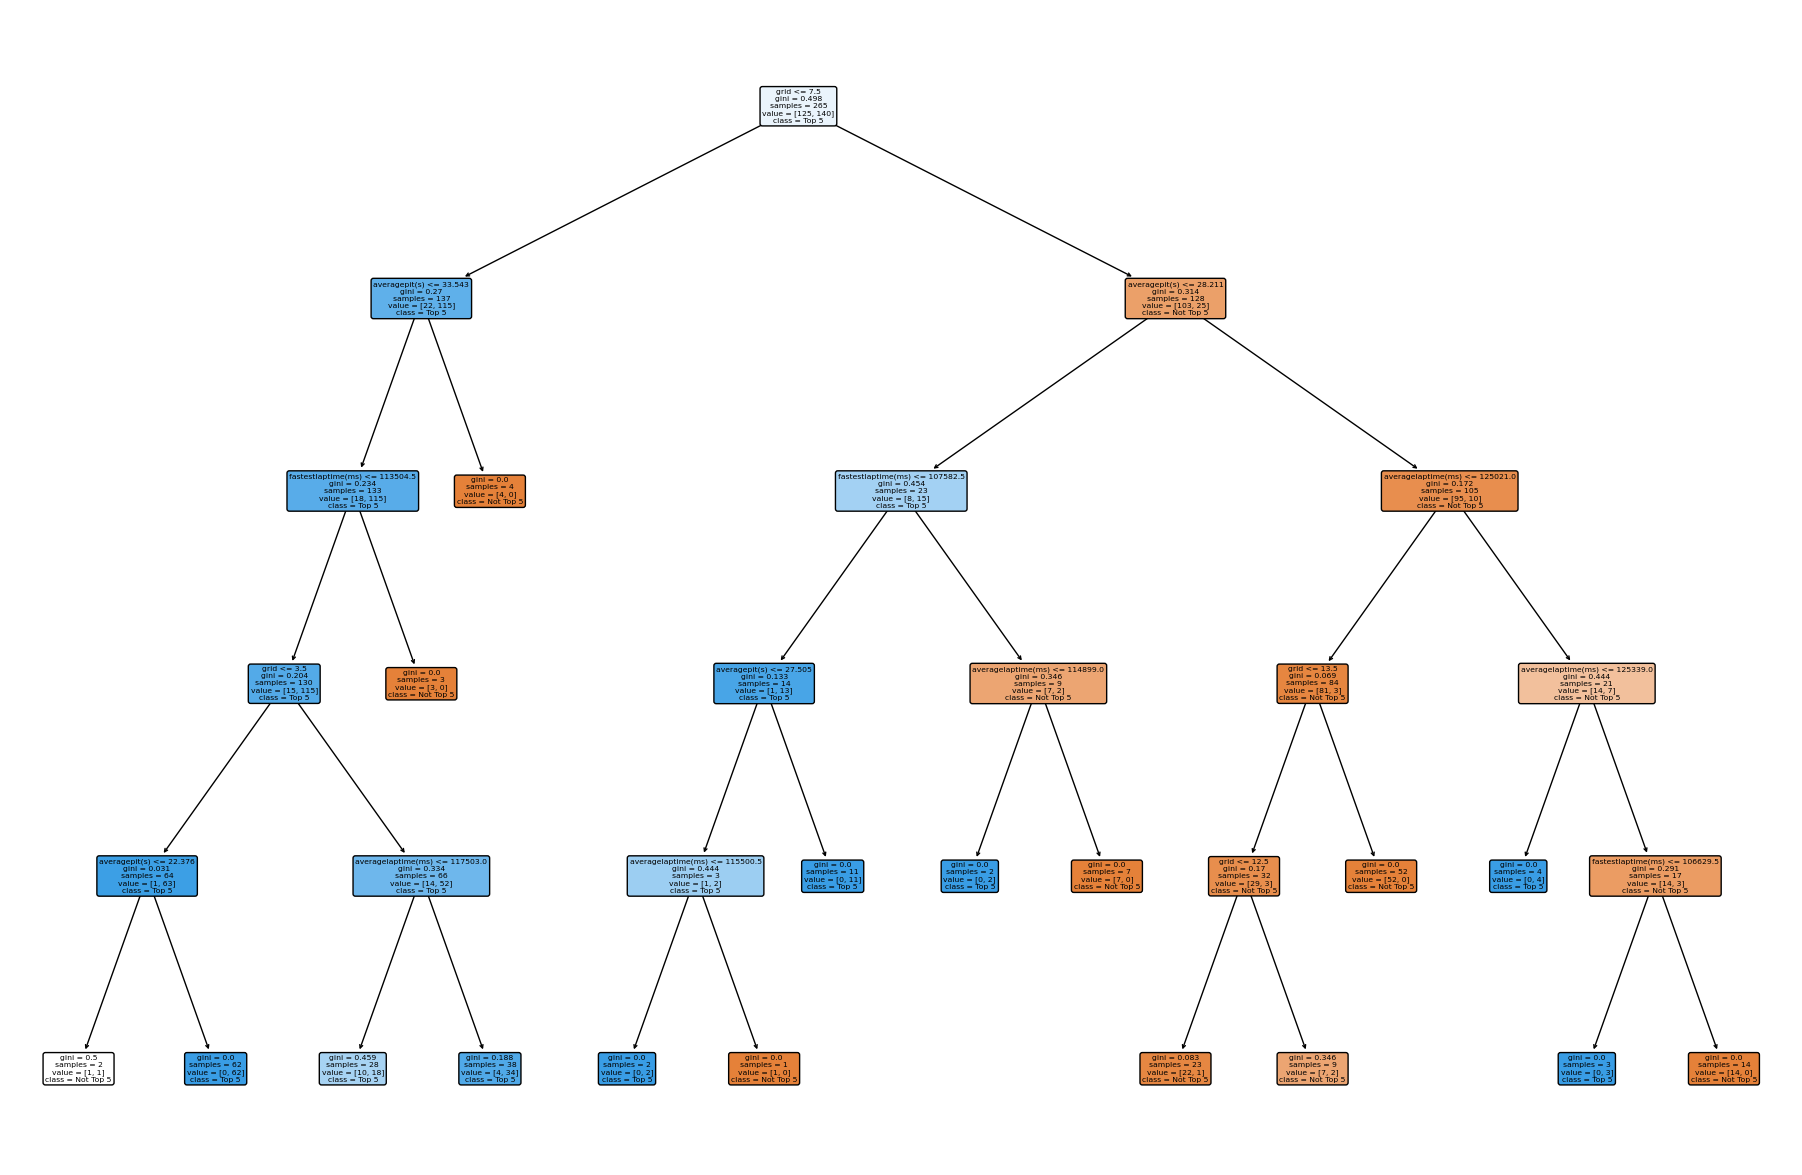

In [61]:
# plot the trained decision tree

from sklearn.tree import plot_tree

f = plt.figure(figsize=(23,15))
plot_tree(dectree, filled=True, rounded=True, 
          feature_names=X_train.columns.tolist(), 
          class_names=["Not Top 5", "Top 5"])

<br><br><br>
<span style="font-family: Courier New; font-size: 20px; font-weight: bold;">  
PREDICTION USING MULTI-VARIATE CLASSIFICATION TREE // MACHINE LEARNING
</span>
<br><br><br>

In [62]:
# extract rows for prediction of results

merge_df3 = merge_df3[merge_df3['averagepit(s)'].notna()]
merge_df3.loc[merge_df3['position'] == -1, 'position'] = 0 # set DNF to -1
mergedf_pred = merge_df3[merge_df3["driverId"].isin(["VER"])]

In [63]:
# extract predictors for prediction
X_pred = pd.DataFrame(mergedf_pred[predictors])

# predict response corresponding to predictors
y_pred = dectree.predict(X_pred)
y_pred # print the predictions of legendary.

array([0, 0, 0, 0, 1, 1, 1, 0])

In [64]:
# summarize the actuals and predictions
y_pred = pd.DataFrame(y_pred, columns = ["PredPosition"], index = mergedf_pred.index)
mergedf_acc = pd.concat([mergedf_pred[["driverId", "raceId", "position"]], y_pred], axis = 1)

mergedf_acc # print the comparison of their actual status vs the predicted.

,driverId,raceId,position,PredPosition
82,VER,2012,0,0
88,VER,2013,0,0
119,VER,2014,0,0
133,VER,2015,0,0
152,VER,2016,0,1
193,VER,2018,1,1
214,VER,2019,1,1
229,VER,2022,0,0


<br><br>
<span style="font-family: Courier New; font-size: 20px; font-weight: bold;">  
SUPPORT VECTOR MACHINE (SVM) // MACHINE LEARNING
</span>
<br><br><br>

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
def SVM(X, y, test_size = 0.25, cv = 10):
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
    
    # Initialize the Logistic Regression model
    model = SVC()
    
    # Fit the model on the training data
    model.fit(X_train, y_train)
    
    # Make predictions on the test data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    print("Support Vector Classification: \n")

    # Calculate cross-validation score
    cv_scores = cross_val_score(model, X, y, cv=cv)
    
    # Print cross-validation score
    print("Cross-Validation Scores:", cv_scores)
    print("Mean Accuracy:", np.mean(cv_scores))
    print()
    
    
    # Print classification report
    print("Classification Report:")
    print(classification_report(y_test, y_test_pred))
    print()
    
    
    tntrain, fptrain, fntrain, tptrain = confusion_matrix(y_train, y_train_pred).ravel()
    tntest, fptest, fntest, tptest = confusion_matrix(y_test, y_test_pred).ravel()

    print("\t\t Train Dataset")
    print("Classification Accuracy\t\t:", model.score(X_train, y_train))
    print()

    print("\t\t Test Dataset")
    print("Classification Accuracy\t\t:", model.score(X_test, y_test))
    print()
    
    print("\t\t Train Dataset")
    print("True Positive Rate\t\t:", rate(tptrain, fntrain))
    print()

    print("\t\t Test Dataset")
    print("True Positive Rate\t\t:", rate(tptest, fntest))
    print()

    print("\t\t Train Dataset")
    print("True Negative Rate\t\t:", rate(tntrain, fptrain))
    print()

    print("\t\t Test Dataset")
    print("True Negative Rate\t\t:", rate(tntest, fptest))
    print()

    print("\t\t Train Dataset")
    print("False Positive Rate\t\t:", rate(fptrain, tntrain))
    print()

    print("\t\t Test Dataset")
    print("False Positive Rate\t\t:", rate(fptest, tntest))
    print()

    print("\t\t Train Dataset")
    print("False Negative Rate\t\t:", rate(fntrain, tptrain))
    print()

    print("\t\t Test Dataset")
    print("False Negative Rate\t\t:", rate(fntest, tptest))
    print()
    
    # Print confusion matrix
    print("Confusion Matrix:")
    f, axes = plt.subplots(1, 2, figsize=(12, 4))
    sb.heatmap(confusion_matrix(y_train, y_train_pred),
                annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0], cmap="PuBu")
    sb.heatmap(confusion_matrix(y_test, y_test_pred), 
                annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1], cmap="PuBu")

Support Vector Classification: 

Cross-Validation Scores: [0.36111111 0.55555556 0.69444444 0.61111111 0.54285714 0.57142857
 0.45714286 0.57142857 0.4        0.62857143]
Mean Accuracy: 0.5393650793650794

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.02      0.04        47
           1       0.48      1.00      0.65        42

    accuracy                           0.48        89
   macro avg       0.74      0.51      0.34        89
weighted avg       0.75      0.48      0.33        89


		 Train Dataset
Classification Accuracy		: 0.5132075471698113

		 Test Dataset
Classification Accuracy		: 0.48314606741573035

		 Train Dataset
True Positive Rate		: 1.0

		 Test Dataset
True Positive Rate		: 1.0

		 Train Dataset
True Negative Rate		: 0.007692307692307693

		 Test Dataset
True Negative Rate		: 0.02127659574468085

		 Train Dataset
False Positive Rate		: 0.9923076923076923

		 Test Dataset
False Positive Rate		: 0.9787234

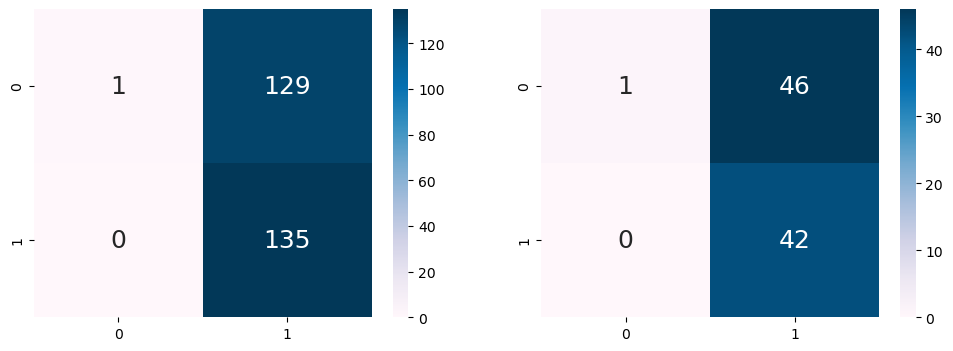

In [66]:
SVM(mldf_up_pred, mldf_up_res)

<br><br>
<span style="font-family: Courier New; font-size: 20px; font-weight: bold;">  
LOGISTIC REGRESSION // MACHINE LEARNING
</span>
<br><br><br>

In [67]:
def LogisticRegression(X, y, test_size = 0.25, cv = 10):
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
    from sklearn.model_selection import cross_val_score
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
    
    # Initialize the Logistic Regression model
    model = LogisticRegression()
    
    # Fit the model on the training data
    model.fit(X_train, y_train)
    
    # Make predictions on the test data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    print("Logistic Regression: \n")
    
    # Calculate cross-validation score
    cv_scores = cross_val_score(model, X, y, cv=cv)
    
    # Print cross-validation score
    print("Cross-Validation Scores:", cv_scores)
    print("Mean Accuracy:", np.mean(cv_scores))
    print()
    
    
    # Print classification report
    print("Classification Report:")
    print(classification_report(y_test, y_test_pred))
    print()
    
    
    tntrain, fptrain, fntrain, tptrain = confusion_matrix(y_train, y_train_pred).ravel()
    tntest, fptest, fntest, tptest = confusion_matrix(y_test, y_test_pred).ravel()

    print("\t\t Train Dataset")
    print("Classification Accuracy\t\t:", model.score(X_train, y_train))
    print()

    print("\t\t Test Dataset")
    print("Classification Accuracy\t\t:", model.score(X_test, y_test))
    print()
    
    print("\t\t Train Dataset")
    print("True Positive Rate\t\t:", rate(tptrain, fntrain))
    print()

    print("\t\t Test Dataset")
    print("True Positive Rate\t\t:", rate(tptest, fntest))
    print()

    print("\t\t Train Dataset")
    print("True Negative Rate\t\t:", rate(tntrain, fptrain))
    print()

    print("\t\t Test Dataset")
    print("True Negative Rate\t\t:", rate(tntest, fptest))
    print()

    print("\t\t Train Dataset")
    print("False Positive Rate\t\t:", rate(fptrain, tntrain))
    print()

    print("\t\t Test Dataset")
    print("False Positive Rate\t\t:", rate(fptest, tntest))
    print()

    print("\t\t Train Dataset")
    print("False Negative Rate\t\t:", rate(fntrain, tptrain))
    print()

    print("\t\t Test Dataset")
    print("False Negative Rate\t\t:", rate(fntest, tptest))
    print()
    
    
    # Print confusion matrix
    print("Confusion Matrix:")
    f, axes = plt.subplots(1, 2, figsize=(12, 4))
    sb.heatmap(confusion_matrix(y_train, y_train_pred),
                annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0], cmap="PuBu")
    sb.heatmap(confusion_matrix(y_test, y_test_pred), 
                annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1], cmap="PuBu")

Logistic Regression: 

Cross-Validation Scores: [0.69444444 0.83333333 0.83333333 0.86111111 0.77142857 0.85714286
 0.82857143 0.82857143 0.85714286 0.77142857]
Mean Accuracy: 0.8136507936507936

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.78      0.81        46
           1       0.78      0.84      0.81        43

    accuracy                           0.81        89
   macro avg       0.81      0.81      0.81        89
weighted avg       0.81      0.81      0.81        89


		 Train Dataset
Classification Accuracy		: 0.8301886792452831

		 Test Dataset
Classification Accuracy		: 0.8089887640449438

		 Train Dataset
True Positive Rate		: 0.8880597014925373

		 Test Dataset
True Positive Rate		: 0.8372093023255814

		 Train Dataset
True Negative Rate		: 0.7709923664122137

		 Test Dataset
True Negative Rate		: 0.782608695652174

		 Train Dataset
False Positive Rate		: 0.22900763358778625

		 Test Dataset
False Positive R

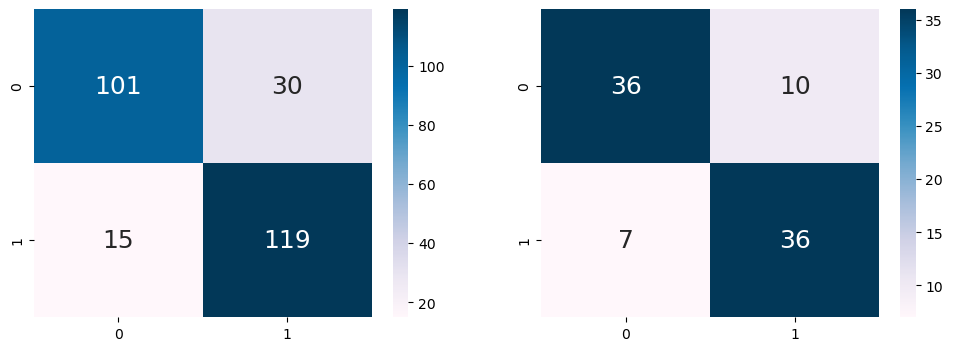

In [68]:
LogisticRegression(mldf_up_pred, mldf_up_res)

<br><br><br>
<span style="font-family: Courier New; font-size: 20px; font-weight: bold;">  
Random Forest Classification // Machine Learning
</span>
<br><br><br>

In [69]:
# Import essential models and functions from sklearn
from sklearn.model_selection import train_test_split

# Extract Response and Predictors
y = pd.DataFrame(mldf_up['position'])
X = pd.DataFrame(mldf_up.drop('position', axis = 1))

# Split the Dataset into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

# Import RandomForestClassifier model from Scikit-Learn
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest object
rforest = RandomForestClassifier(n_estimators = 100, max_depth = 5)     

# Fit Random Forest on Train Data
rforest.fit(X_train, y_train.position.ravel())

RandomForestClassifier(max_depth=5)

Cross-Validation Scores: [0.72222222 0.80555556 0.91666667 0.88888889 0.85714286 0.94285714
 0.88571429 0.94285714 0.91428571 0.94285714]
Mean Accuracy: 0.8819047619047617

		 Train Dataset
Classification Accuracy		: 0.9358490566037736

		 Test Dataset
Classification Accuracy		: 0.9550561797752809

		 Train Dataset
True Positive Rate		: 0.9844961240310077

		 Test Dataset
True Positive Rate		: 0.9791666666666666

		 Train Dataset
True Negative Rate		: 0.8897058823529411

		 Test Dataset
True Negative Rate		: 0.926829268292683

		 Train Dataset
False Positive Rate		: 0.11029411764705882

		 Test Dataset
False Positive Rate		: 0.07317073170731707

		 Train Dataset
False Negative Rate		: 0.015503875968992248

		 Test Dataset
False Negative Rate		: 0.020833333333333332



<Axes: >

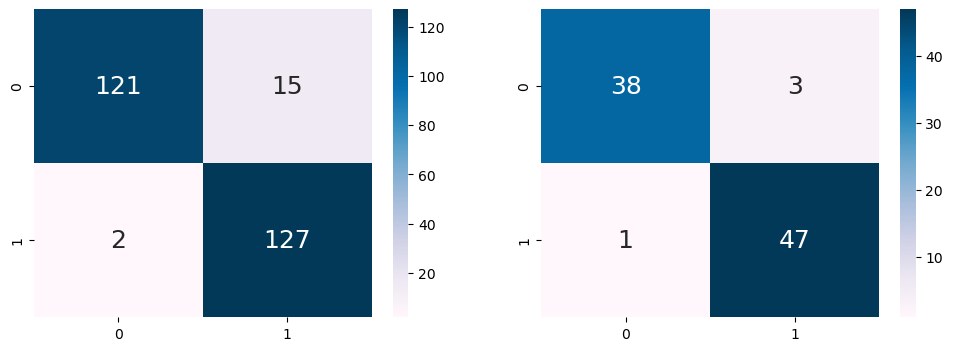

In [106]:
# Import confusion_matrix from Scikit-Learn
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score

# Predict the Response corresponding to Predictors
y_train_pred = rforest.predict(X_train)

# Predict the Response corresponding to Predictors
y_test_pred = rforest.predict(X_test)

    
# Calculate cross-validation score
cv_scores = cross_val_score(rforest, X, y, cv=10)
    
# Print cross-validation score
print("Cross-Validation Scores:", cv_scores)
print("Mean Accuracy:", np.mean(cv_scores))
print()

tntrain, fptrain, fntrain, tptrain = confusion_matrix(y_train, y_train_pred).ravel()
tntest, fptest, fntest, tptest = confusion_matrix(y_test, y_test_pred).ravel()

print("\t\t Train Dataset")
print("Classification Accuracy\t\t:", rforest.score(X_train, y_train))
print()

print("\t\t Test Dataset")
print("Classification Accuracy\t\t:", rforest.score(X_test, y_test))
print()

print("\t\t Train Dataset")
print("True Positive Rate\t\t:", rate(tptrain, fntrain))
print()

print("\t\t Test Dataset")
print("True Positive Rate\t\t:", rate(tptest, fntest))
print()

print("\t\t Train Dataset")
print("True Negative Rate\t\t:", rate(tntrain, fptrain))
print()

print("\t\t Test Dataset")
print("True Negative Rate\t\t:", rate(tntest, fptest))
print()

print("\t\t Train Dataset")
print("False Positive Rate\t\t:", rate(fptrain, tntrain))
print()

print("\t\t Test Dataset")
print("False Positive Rate\t\t:", rate(fptest, tntest))
print()

print("\t\t Train Dataset")
print("False Negative Rate\t\t:", rate(fntrain, tptrain))
print()

print("\t\t Test Dataset")
print("False Negative Rate\t\t:", rate(fntest, tptest))
print()

f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(y_train, y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0], cmap="PuBu")
sb.heatmap(confusion_matrix(y_test, y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1], cmap="PuBu")

<br><br>
<span style="font-family: Courier New; font-size: 20px; font-weight: bold;">  
SVM WITH GRIDSEARCHCV // MACHINE LEARNING
</span>
<br><br><br>

In [118]:
# Increasing the accuracy of the models by optimising the parameters using GridSearchCV

from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(mldf_up_pred, mldf_up_res, test_size=0.25)

svm_model = SVC()

# Make a dictionary of hyperparameters values to search

search_space = {
    'kernel' : ['rbf', 'poly', 'sigmoid', 'linear'],
    'C' : [0.1, 1, 100, 1000],
    'degree' : [1,3,5,7,9]
}

In [119]:
from sklearn.model_selection import GridSearchCV

# Make a gridsearch object

GS = GridSearchCV(estimator = svm_model,
                 param_grid = search_space,
                 scoring = ['f1', 'accuracy', 'precision'],
                 refit = 'f1',
                 cv = 4,
                 n_jobs=-1)

In [120]:
GS.fit(X_train,y_train)

GridSearchCV(cv=4, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 100, 1000], 'degree': [1, 3, 5, 7, 9],
                         'kernel': ['rbf', 'poly', 'sigmoid', 'linear']},
             refit='f1', scoring=['f1', 'accuracy', 'precision'])

In [121]:
print(GS.best_estimator_)

SVC(C=1000, degree=9, kernel='poly')


In [122]:
print(GS.best_score_)

0.7871965432941042


In [123]:
# Redoing the SVM with optimised parameters
def SVM2(X, y, test_size = 0.25, cv = 10):
    # Split the data into training and testing sets
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
    
    # Initialize the Logistic Regression model
    model = SVC(C=1000, degree=9, kernel='poly')
    
    # Fit the model on the training data
    model.fit(X_train, y_train)
    
    # Make predictions on the test data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    print("Support Vector Classification: \n")
    
    # Calculate cross-validation score
    cv_scores = cross_val_score(model, X, y, cv=cv)
    
    # Print cross-validation score
    print("Cross-Validation Scores:", cv_scores)
    print("Mean Accuracy:", np.mean(cv_scores))
    print()
    
    
    # Print classification report
    print("Classification Report:")
    print(classification_report(y_test, y_test_pred))
    print()
    
    
    tntrain, fptrain, fntrain, tptrain = confusion_matrix(y_train, y_train_pred).ravel()
    tntest, fptest, fntest, tptest = confusion_matrix(y_test, y_test_pred).ravel()

    print("\t\t Train Dataset")
    print("Classification Accuracy\t\t:", model.score(X_train, y_train))
    print()

    print("\t\t Test Dataset")
    print("Classification Accuracy\t\t:", model.score(X_test, y_test))
    print()

    print("\t\t Train Dataset")
    print("True Positive Rate\t\t:", rate(tptrain, fntrain))
    print()

    print("\t\t Test Dataset")
    print("True Positive Rate\t\t:", rate(tptest, fntest))
    print()

    print("\t\t Train Dataset")
    print("True Negative Rate\t\t:", rate(tntrain, fptrain))
    print()

    print("\t\t Test Dataset")
    print("True Negative Rate\t\t:", rate(tntest, fptest))
    print()

    print("\t\t Train Dataset")
    print("False Positive Rate\t\t:", rate(fptrain, tntrain))
    print()

    print("\t\t Test Dataset")
    print("False Positive Rate\t\t:", rate(fptest, tntest))
    print()

    print("\t\t Train Dataset")
    print("False Negative Rate\t\t:", rate(fntrain, tptrain))
    print()

    print("\t\t Test Dataset")
    print("False Negative Rate\t\t:", rate(fntest, tptest))
    print()
    print()
    
    # Print confusion matrix
    print("Confusion Matrix:")
    f, axes = plt.subplots(1, 2, figsize=(12, 4))
    sb.heatmap(confusion_matrix(y_train, y_train_pred),
                annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0], cmap="PuBu")
    sb.heatmap(confusion_matrix(y_test, y_test_pred), 
                annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1], cmap="PuBu")

Support Vector Classification: 

Cross-Validation Scores: [0.58333333 0.75       0.91666667 0.94444444 0.82857143 0.91428571
 0.88571429 0.65714286 0.45714286 0.48571429]
Mean Accuracy: 0.7423015873015874

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.53      0.65        40
           1       0.70      0.92      0.80        49

    accuracy                           0.74        89
   macro avg       0.77      0.72      0.72        89
weighted avg       0.76      0.74      0.73        89


		 Train Dataset
Classification Accuracy		: 0.7773584905660378

		 Test Dataset
Classification Accuracy		: 0.7415730337078652

		 Train Dataset
True Positive Rate		: 0.890625

		 Test Dataset
True Positive Rate		: 0.9183673469387755

		 Train Dataset
True Negative Rate		: 0.6715328467153284

		 Test Dataset
True Negative Rate		: 0.525

		 Train Dataset
False Positive Rate		: 0.3284671532846715

		 Test Dataset
False Positive Rate		: 0.475


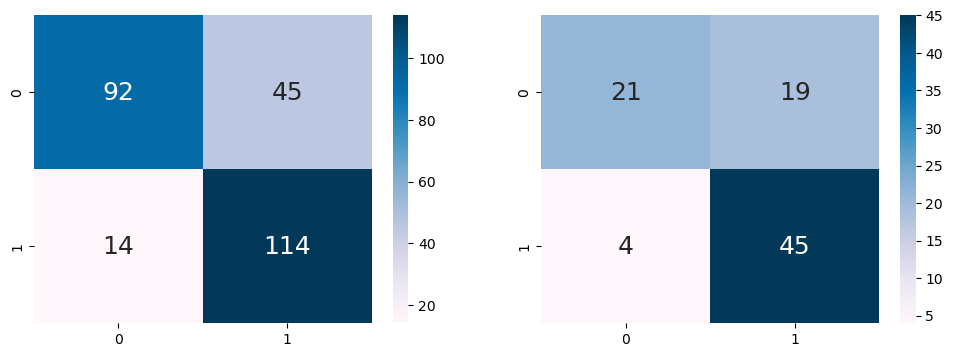

In [124]:
SVM2(mldf_up_pred, mldf_up_res)
print()

<br><br>
<span style="font-family: Courier New; font-size: 20px; font-weight: bold;">  
LOGISTIC REGRESSION WITH GRIDSEARCHCV // MACHINE LEARNING
</span>
<br><br><br>

In [143]:
# Increasing the accuracy of the models by optimising the parameters using GridSearchCV

from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(mldf_up_pred, mldf_up_res, test_size=0.25)

log_model = LogisticRegression()

# Make a dictionary of hyperparameters values to search
# We do not include penalty none to prevent overfitting
search_space2 = {
    'penalty' : ['l1', 'l2', 'elasticnet'],
    'C' : np.logspace(-4, 4, 20),
    'max_iter' : [100, 1000, 2500, 5000],
    'solver' : ['lbfgs', 'newton-cg', 'liblinear', 'sag', 'saga']
}

In [148]:
from sklearn.model_selection import GridSearchCV

# Make a gridsearch object
GS2 = GridSearchCV(estimator = log_model,
                 param_grid = search_space2,
                 scoring = ['f1', 'accuracy', 'precision'],
                 refit = 'f1',
                 cv = 4,
                 n_jobs=-1)

In [149]:
GS2.fit(X_train, y_train)

GridSearchCV(cv=4, estimator=LogisticRegression(), n_jobs=1,
             param_grid={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                         'max_iter': [100, 1000, 2500, 5000],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['lbfgs', 'newton-cg', 'liblinear', 'sag',
                                    'saga']},
             refit='f1', scoring=['f1', 'accuracy', 'precision'])

In [150]:
print(GS2.best_estimator_)

LogisticRegression(C=0.012742749857031334, max_iter=1000, solver='newton-cg')


In [151]:
print(GS2.best_score_)

0.8551342665554217


In [152]:
# Redoing the Logistic Regression with optimised parameters

def LogisticRegression2(X, y, test_size = 0.25, cv =10):
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
    
    # Initialize the Logistic Regression model
    model = LogisticRegression(C=0.012742749857031334, solver='newton-cg')
    
    # Fit the model on the training data
    model.fit(X_train, y_train)
    
    # Make predictions on the test data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    print("Logistic Regression: \n")
    
    # Calculate cross-validation score
    cv_scores = cross_val_score(model, X, y, cv=cv)
    
    # Print cross-validation score
    print("Cross-Validation Scores:", cv_scores)
    print("Mean Accuracy:", np.mean(cv_scores))
    print()
    
    
    # Print classification report
    print("Classification Report:")
    print(classification_report(y_test, y_test_pred))
    print()
    
    
    tntrain, fptrain, fntrain, tptrain = confusion_matrix(y_train, y_train_pred).ravel()
    tntest, fptest, fntest, tptest = confusion_matrix(y_test, y_test_pred).ravel()

    print("\t\t Train Dataset")
    print("Classification Accuracy\t\t:", model.score(X_train, y_train))
    print()

    print("\t\t Test Dataset")
    print("Classification Accuracy\t\t:", model.score(X_test, y_test))
    print()
    
    print("\t\t Train Dataset")
    print("True Positive Rate\t\t:", rate(tptrain, fntrain))
    print()

    print("\t\t Test Dataset")
    print("True Positive Rate\t\t:", rate(tptest, fntest))
    print()

    print("\t\t Train Dataset")
    print("True Negative Rate\t\t:", rate(tntrain, fptrain))
    print()

    print("\t\t Test Dataset")
    print("True Negative Rate\t\t:", rate(tntest, fptest))
    print()

    print("\t\t Train Dataset")
    print("False Positive Rate\t\t:", rate(fptrain, tntrain))
    print()

    print("\t\t Test Dataset")
    print("False Positive Rate\t\t:", rate(fptest, tntest))
    print()

    print("\t\t Train Dataset")
    print("False Negative Rate\t\t:", rate(fntrain, tptrain))
    print()

    print("\t\t Test Dataset")
    print("False Negative Rate\t\t:", rate(fntest, tptest))
    print()
    print()
    
    # Print confusion matrix
    print("Confusion Matrix:")
    f, axes = plt.subplots(1, 2, figsize=(12, 4))
    sb.heatmap(confusion_matrix(y_train, y_train_pred),
                annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0], cmap="PuBu")
    sb.heatmap(confusion_matrix(y_test, y_test_pred), 
                annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1], cmap="PuBu")

Logistic Regression: 

Cross-Validation Scores: [0.75       0.80555556 0.91666667 0.88888889 0.82857143 0.94285714
 0.85714286 0.8        0.8        0.77142857]
Mean Accuracy: 0.836111111111111

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91        43
           1       0.93      0.89      0.91        46

    accuracy                           0.91        89
   macro avg       0.91      0.91      0.91        89
weighted avg       0.91      0.91      0.91        89


		 Train Dataset
Classification Accuracy		: 0.8415094339622642

		 Test Dataset
Classification Accuracy		: 0.9101123595505618

		 Train Dataset
True Positive Rate		: 0.8778625954198473

		 Test Dataset
True Positive Rate		: 0.8913043478260869

		 Train Dataset
True Negative Rate		: 0.8059701492537313

		 Test Dataset
True Negative Rate		: 0.9302325581395349

		 Train Dataset
False Positive Rate		: 0.19402985074626866

		 Test Dataset
False Positive R

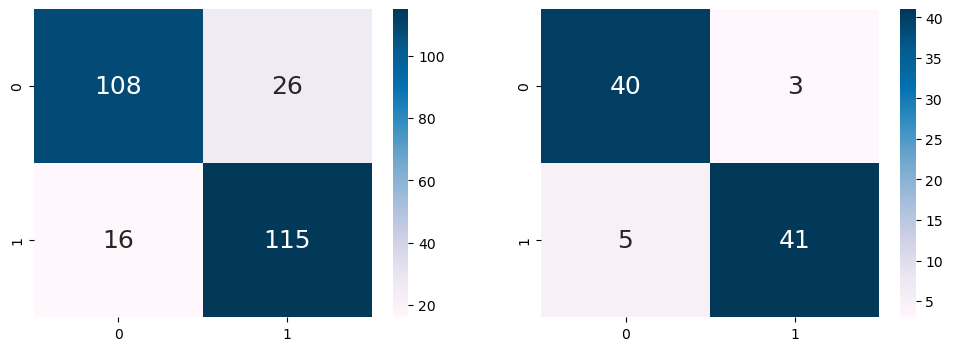

In [153]:
LogisticRegression2(mldf_up_pred, mldf_up_res)

<br><br><br>
<span style="font-family: Courier New; font-size: 20px; font-weight: bold;">  
RANDOM FOREST WITH GRIDSEARCHCV // MACHINE LEARNING
</span>
<br><br><br>

In [154]:
# Optimising parameters using GridSearchCV

from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(mldf_up_pred, mldf_up_res, test_size=0.25)

RF_model = RandomForestClassifier()

search_space3 = {
    'n_estimators' : [100,500,1000,1500],
    'max_depth' : [4,5,6],
    'max_samples' : [0.25,0.5,0.75,1.0],
    'max_features' : ['sqrt', 'log2', 0.2, 0.4, 0.6, 0.8, 1.0]
}

In [155]:
GS3 = GridSearchCV(estimator = RF_model,
                  param_grid = search_space3,
                  cv = 4,
                  scoring = ['f1', 'accuracy', 'precision'],
                  refit = 'f1',
                  verbose = 0,
                  n_jobs = -1)

In [156]:
GS3.fit(X_train, y_train)

GridSearchCV(cv=4, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [4, 5, 6],
                         'max_features': ['sqrt', 'log2', 0.2, 0.4, 0.6, 0.8,
                                          1.0],
                         'max_samples': [0.25, 0.5, 0.75, 1.0],
                         'n_estimators': [100, 500, 1000, 1500]},
             refit='f1', scoring=['f1', 'accuracy', 'precision'])

In [157]:
print(GS3.best_estimator_)

RandomForestClassifier(max_depth=6, max_features='log2', max_samples=1.0,
                       n_estimators=500)


In [158]:
print(GS3.best_score_)

0.9262195515926859


In [159]:
# Using Optimised parameters
from sklearn.model_selection import train_test_split

# Extract Response and Predictors
y = pd.DataFrame(mldf_up_res)
X = pd.DataFrame(mldf_up_pred)

# Split the Dataset into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

# Import RandomForestClassifier model from Scikit-Learn
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest object
rforest = RandomForestClassifier(max_depth=6, max_features=1.0, max_samples=1.0,
                       n_estimators=1000)

# Fit Random Forest on Train Data
rforest.fit(X_train, y_train.position.ravel())

RandomForestClassifier(max_depth=6, max_features=1.0, max_samples=1.0,
                       n_estimators=1000)

Cross-Validation Scores: [0.77777778 0.77777778 0.97222222 0.94444444 0.85714286 0.91428571
 0.91428571 0.91428571 0.91428571 0.85714286]
Mean Accuracy: 0.8843650793650794

		 Train Dataset
Classification Accuracy		: 0.9622641509433962

		 Test Dataset
Classification Accuracy		: 0.9662921348314607

		 Train Dataset
True Positive Rate		: 0.9922480620155039

		 Test Dataset
True Positive Rate		: 0.9791666666666666

		 Train Dataset
True Negative Rate		: 0.9338235294117647

		 Test Dataset
True Negative Rate		: 0.9512195121951219

		 Train Dataset
False Positive Rate		: 0.0661764705882353

		 Test Dataset
False Positive Rate		: 0.04878048780487805

		 Train Dataset
False Negative Rate		: 0.007751937984496124

		 Test Dataset
False Negative Rate		: 0.020833333333333332



<Axes: >

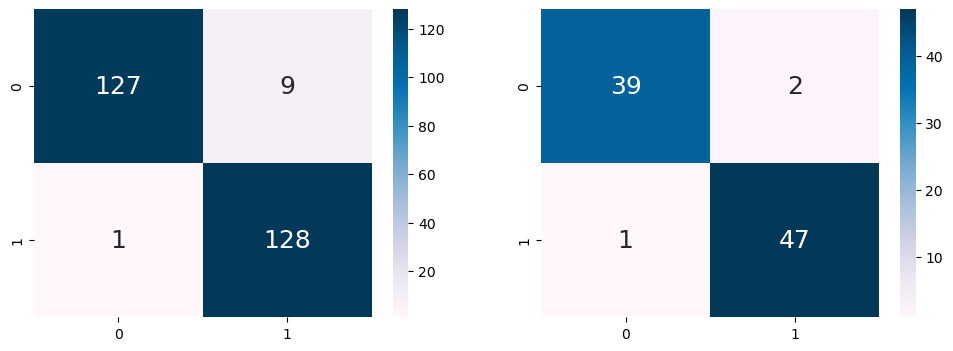

In [160]:
# Import confusion_matrix from Scikit-Learn
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score

# Predict the Response corresponding to Predictors
y_train_pred = rforest.predict(X_train)

# Predict the Response corresponding to Predictors
y_test_pred = rforest.predict(X_test)

# Calculate cross-validation score
cv_scores = cross_val_score(rforest, X, y, cv=10)
    
# Print cross-validation score
print("Cross-Validation Scores:", cv_scores)
print("Mean Accuracy:", np.mean(cv_scores))
print()

tntrain, fptrain, fntrain, tptrain = confusion_matrix(y_train, y_train_pred).ravel()
tntest, fptest, fntest, tptest = confusion_matrix(y_test, y_test_pred).ravel()

print("\t\t Train Dataset")
print("Classification Accuracy\t\t:", rforest.score(X_train, y_train))
print()

print("\t\t Test Dataset")
print("Classification Accuracy\t\t:", rforest.score(X_test, y_test))
print()

print("\t\t Train Dataset")
print("True Positive Rate\t\t:", rate(tptrain, fntrain))
print()

print("\t\t Test Dataset")
print("True Positive Rate\t\t:", rate(tptest, fntest))
print()

print("\t\t Train Dataset")
print("True Negative Rate\t\t:", rate(tntrain, fptrain))
print()

print("\t\t Test Dataset")
print("True Negative Rate\t\t:", rate(tntest, fptest))
print()

print("\t\t Train Dataset")
print("False Positive Rate\t\t:", rate(fptrain, tntrain))
print()

print("\t\t Test Dataset")

print("False Positive Rate\t\t:", rate(fptest, tntest))
print()

print("\t\t Train Dataset")
print("False Negative Rate\t\t:", rate(fntrain, tptrain))
print()

print("\t\t Test Dataset")
print("False Negative Rate\t\t:", rate(fntest, tptest))
print()

f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(y_train, y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0], cmap="PuBu")
sb.heatmap(confusion_matrix(y_test, y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1], cmap="PuBu")